# Positional XGBoost Modeling (Regression)

This notebook trains a **separate XGBoost regressor for each final position group** using files in `data/modeling_datasets/final/*_modeling_with_target.csv`.

Key design choices:
- Chronological split by recruit `year` (train/val/test).
- Direct regression on `target_career_score_0_100`.
- Leakage-safe feature policy (exclude bridge/match fields).
- Light randomized hyperparameter tuning per position.
- Tier bins applied **post-training** for diagnostic classification views.

In [30]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterSampler, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
N_TUNING_ITER = 12
N_FOLDS = 5
MAX_RECRUIT_YEAR = 2021
PREDICT_YEAR_MIN = 2022
PREDICT_YEAR_MAX = 2028
N_CALIBRATION_Q = 101

PROJECT_ROOT = Path.cwd().parent
FINAL_DIR = PROJECT_ROOT / "data" / "modeling_datasets" / "final"
MODEL_DIR = FINAL_DIR / "models" / "xgboost_positional"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FINAL_POSITION_GROUPS = ["DB", "EDGE", "IDL", "LB", "OL", "QB", "RB", "SPEC", "TE", "WR"]

# Optional map for future inference pipelines using raw position labels
POS_MAP = {
    "CB": "DB", "S": "DB", "FS": "DB", "SS": "DB", "DB": "DB",
    "DE": "EDGE", "EDGE": "EDGE",
    "DT": "IDL", "NT": "IDL", "DL": "IDL",
    "LB": "LB", "OLB": "LB", "ILB": "LB", "MLB": "LB",
    "OL": "OL", "OT": "OL", "OG": "OL", "C": "OL",
    "QB": "QB", "PRO": "QB", "DUAL": "QB",
    "RB": "RB", "HB": "RB", "FB": "RB",
    "K": "SPEC", "P": "SPEC", "PK": "SPEC", "LS": "SPEC", "RET": "SPEC", "SPEC": "SPEC",
    "TE": "TE",
    "WR": "WR",
}

# Torch seeding + Intel GPU detection (Arc B580)
import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

intel_ipex_available = False
try:
    import intel_extension_for_pytorch as ipex
    _ = ipex
    intel_ipex_available = True
except Exception:
    intel_ipex_available = False

has_xpu = hasattr(torch, "xpu") and torch.xpu.is_available()
if intel_ipex_available and has_xpu:
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

def resolve_xgb_device(preferred_device: str = "gpu") -> str:
    if preferred_device != "gpu":
        return preferred_device
    try:
        probe_model = XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            device="gpu",
            n_estimators=1,
            max_depth=1,
            learning_rate=0.1,
            random_state=SEED,
            n_jobs=1,
        )
        probe_X = np.array([[0.0], [1.0], [2.0]], dtype=float)
        probe_y = np.array([0.0, 1.0, 2.0], dtype=float)
        probe_model.fit(probe_X, probe_y)
        return "gpu"
    except Exception as exc:
        print(f"XGBoost gpu unavailable in this build; falling back to cpu. Details: {exc}")
        return "cpu"

XGB_DEVICE = resolve_xgb_device("gpu" if has_xpu else "cpu")
XGB_TREE_METHOD = "hist"

print(f"Final data dir: {FINAL_DIR}")
print(f"Model output dir: {MODEL_DIR}")
print(f"Tuning iterations per position: {N_TUNING_ITER}")
print(f"CV folds: {N_FOLDS}")
print(f"Training years: <= {MAX_RECRUIT_YEAR}")
print(f"Future scoring years: {PREDICT_YEAR_MIN}-{PREDICT_YEAR_MAX}")
print(f"Calibration quantiles: {N_CALIBRATION_Q}")
print(f"Torch device: {device}")
print(f"IPEX available: {intel_ipex_available}")
print(f"XGBoost device: {XGB_DEVICE} ({XGB_TREE_METHOD})")

Final data dir: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final
Model output dir: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final\models\xgboost_positional
Tuning iterations per position: 12
CV folds: 5
Training years: <= 2021
Future scoring years: 2022-2028
Calibration quantiles: 101
Torch device: xpu
IPEX available: True
XGBoost device: gpu (hist)


In [31]:
TIER_BINS = [0.0, 20.0, 40.0, 60.0, 80.0, 100.0001]
TIER_LABELS = ["T1", "T2", "T3", "T4", "T5"]
SKILL_PREFIX = "skill_"
FLAG_PREFIX = "flag_"
ALLOWED_FIXED_FEATURES = ["height_inches", "weight_lbs", "rating", "state", "position"]

def bin_scores_to_tier(score_series: pd.Series) -> pd.Series:
    score_numeric = pd.to_numeric(score_series, errors="coerce")
    return pd.cut(
        score_numeric,
        bins=TIER_BINS,
        labels=TIER_LABELS,
        include_lowest=True,
        right=False
    )

def make_strat_labels(y: pd.Series, n_bins: int = N_FOLDS) -> pd.Series:
    y_num = pd.to_numeric(y, errors="coerce")
    try:
        labels = pd.qcut(y_num, q=n_bins, labels=False, duplicates="drop")
    except Exception:
        labels = bin_scores_to_tier(y_num).cat.codes
    labels = pd.Series(labels).fillna(0).astype(int)
    return labels

def is_skill_rating_column(col_name: str) -> bool:
    col_norm = col_name.lower().strip()
    return col_norm.startswith(SKILL_PREFIX)

def select_model_feature_candidates(df: pd.DataFrame) -> list[str]:
    selected = [col for col in ALLOWED_FIXED_FEATURES if col in df.columns]

    for col in df.columns:
        col_norm = col.lower().strip()
        if col_norm.startswith(FLAG_PREFIX) or col_norm.startswith(SKILL_PREFIX):
            if col not in selected:
                selected.append(col)

    return selected

def infer_column_types(df: pd.DataFrame, candidate_cols: list[str], numeric_threshold: float = 0.9):
    numeric_cols, categorical_cols, dropped_cols = [], [], []
    n_rows = max(len(df), 1)

    for col in candidate_cols:
        col_norm = col.lower().strip()

        if col_norm in {"height_inches", "weight_lbs", "rating"}:
            numeric_cols.append(col)
            continue

        if col_norm in {"state", "position"}:
            categorical_cols.append(col)
            continue

        if col_norm.startswith(FLAG_PREFIX):
            categorical_cols.append(col)
            continue

        if col_norm.startswith(SKILL_PREFIX):
            numeric_series = pd.to_numeric(df[col], errors="coerce")
            non_na_ratio = float(numeric_series.notna().sum()) / n_rows
            if non_na_ratio >= 0.2:
                numeric_cols.append(col)
            else:
                categorical_cols.append(col)
            continue

        dropped_cols.append(col)

    return numeric_cols, categorical_cols, dropped_cols

def build_preprocessor(numeric_cols: list[str], categorical_cols: list[str]) -> ColumnTransformer:
    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ],
        remainder="drop"
    )

def get_feature_names(preprocessor: ColumnTransformer) -> list[str]:
    try:
        return list(preprocessor.get_feature_names_out())
    except Exception:
        return []

def fit_distribution_calibrator(y_true: pd.Series, y_pred: pd.Series, n_quantiles: int = 101) -> dict:
    y_true_num = pd.to_numeric(y_true, errors="coerce")
    y_pred_num = pd.to_numeric(y_pred, errors="coerce")
    valid_mask = y_true_num.notna() & y_pred_num.notna()
    y_true_vals = y_true_num[valid_mask].to_numpy(dtype=float)
    y_pred_vals = y_pred_num[valid_mask].to_numpy(dtype=float)

    if len(y_true_vals) < 10:
        return {"method": "identity", "n": int(len(y_true_vals))}

    quantiles = np.linspace(0.0, 1.0, n_quantiles)
    pred_q = np.quantile(y_pred_vals, quantiles)
    true_q = np.quantile(y_true_vals, quantiles)

    pred_unique, unique_idx = np.unique(pred_q, return_index=True)
    true_unique = true_q[unique_idx]

    if len(pred_unique) < 2:
        pred_mean = float(np.mean(y_pred_vals))
        true_mean = float(np.mean(y_true_vals))
        pred_std = float(np.std(y_pred_vals))
        true_std = float(np.std(y_true_vals))
        scale = (true_std / pred_std) if pred_std > 0 else 1.0
        return {
            "method": "linear",
            "n": int(len(y_true_vals)),
            "pred_mean": pred_mean,
            "true_mean": true_mean,
            "scale": float(scale),
        }

    return {
        "method": "quantile",
        "n": int(len(y_true_vals)),
        "quantiles": quantiles.tolist(),
        "pred_q": pred_unique.tolist(),
        "true_q": true_unique.tolist(),
        "pred_mean": float(np.mean(y_pred_vals)),
        "true_mean": float(np.mean(y_true_vals)),
        "pred_std": float(np.std(y_pred_vals)),
        "true_std": float(np.std(y_true_vals)),
    }

def apply_distribution_calibrator(pred_values, calibrator: dict):
    pred_arr = pd.to_numeric(pd.Series(pred_values), errors="coerce").fillna(0.0).to_numpy(dtype=float)
    method = calibrator.get("method", "identity")

    if method == "quantile":
        pred_q = np.asarray(calibrator.get("pred_q", []), dtype=float)
        true_q = np.asarray(calibrator.get("true_q", []), dtype=float)
        if len(pred_q) >= 2 and len(true_q) == len(pred_q):
            return np.interp(pred_arr, pred_q, true_q, left=true_q[0], right=true_q[-1])
        return pred_arr

    if method == "linear":
        pred_mean = float(calibrator.get("pred_mean", 0.0))
        true_mean = float(calibrator.get("true_mean", pred_mean))
        scale = float(calibrator.get("scale", 1.0))
        return (pred_arr - pred_mean) * scale + true_mean

    return pred_arr

In [32]:
position_files = {pos: FINAL_DIR / f"{pos}_modeling_with_target.csv" for pos in FINAL_POSITION_GROUPS}
missing_files = [pos for pos, path in position_files.items() if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing modeling_with_target files for: {missing_files}")

datasets = {}
inference_datasets = {}
discovery_rows = []

for pos, file_path in position_files.items():
    df_all = pd.read_csv(file_path, dtype=str).fillna("")
    year_numeric_all = pd.to_numeric(df_all.get("year", pd.Series([], dtype=float)), errors="coerce")

    df_train = df_all[year_numeric_all <= MAX_RECRUIT_YEAR].copy()
    df_future = df_all[(year_numeric_all >= PREDICT_YEAR_MIN) & (year_numeric_all <= PREDICT_YEAR_MAX)].copy()

    datasets[pos] = df_train
    inference_datasets[pos] = df_future

    target_numeric_train = pd.to_numeric(df_train.get("target_career_score_0_100", pd.Series([], dtype=float)), errors="coerce")

    discovery_rows.append({
        "position": pos,
        "rows_train": len(df_train),
        "rows_future_2022_2028": len(df_future),
        "columns": len(df_all.columns),
        "target_non_null_train": int(target_numeric_train.notna().sum()),
        "year_min_all": int(year_numeric_all.min()) if year_numeric_all.notna().any() else np.nan,
        "year_max_all": int(year_numeric_all.max()) if year_numeric_all.notna().any() else np.nan,
    })

discovery_df = pd.DataFrame(discovery_rows).sort_values("position")
display(discovery_df)

,position,rows_train,rows_future_2022_2028,columns,target_non_null_train,year_min_all,year_max_all
0,DB,4266,2537,48,2622,2015,2028
1,EDGE,2279,1111,48,613,2015,2028
2,IDL,1734,1544,48,1062,2015,2028
3,LB,3015,1435,48,1666,2015,2028
4,OL,3985,2622,48,2690,2015,2028
5,QB,1706,1080,48,914,2015,2028
6,RB,2144,1037,48,1088,2015,2028
7,SPEC,511,217,38,424,2015,2027
8,TE,1111,831,48,725,2015,2028
9,WR,3402,1978,48,1897,2015,2028


In [25]:
tier_dist_rows = []
for pos, df in datasets.items():
    target_scores = pd.to_numeric(df.get("target_career_score_0_100", pd.NA), errors="coerce")
    target_tiers = bin_scores_to_tier(target_scores)
    counts = target_tiers.value_counts(dropna=False).to_dict()
    row = {"position": pos}
    for label in TIER_LABELS:
        row[label] = int(counts.get(label, 0))
    row["missing_tier"] = int(target_tiers.isna().sum())
    tier_dist_rows.append(row)

tier_distribution_df = pd.DataFrame(tier_dist_rows).sort_values("position")
display(tier_distribution_df)

,position,T1,T2,T3,T4,T5,missing_tier
0,DB,455,271,963,890,43,1644
1,EDGE,169,77,218,133,16,1666
2,IDL,212,105,376,352,17,672
3,LB,388,170,623,454,31,1349
4,OL,804,164,818,850,54,1295
5,QB,293,114,293,190,24,792
6,RB,210,105,428,320,25,1056
7,SPEC,75,33,204,96,16,87
8,TE,171,61,233,240,20,386
9,WR,410,181,814,459,33,1505


In [26]:
# Pre-modeling feature audit: first row + skill-rating count by position
feature_audit_rows = []
first_row_previews = {}

for pos, df in datasets.items():
    if df.empty:
        feature_audit_rows.append({
            "position": pos,
            "rows": 0,
            "model_feature_count": 0,
            "flag_feature_count": 0,
            "skill_feature_count": 0,
            "skill_count_ok_10": False,
            "missing_skill_slots": 10,
        })
        continue

    candidate_cols = select_model_feature_candidates(df)
    numeric_cols, categorical_cols, dropped_cols = infer_column_types(df, candidate_cols)
    model_feature_cols = numeric_cols + categorical_cols

    flag_cols = [c for c in model_feature_cols if c.lower().strip().startswith("flag_")]
    skill_cols = [c for c in model_feature_cols if is_skill_rating_column(c)]

    preview_cols = [c for c in ["player_id", "name", "year", "position", "rating", "height_inches", "weight_lbs", "state"] if c in df.columns]
    preview_cols += [c for c in flag_cols if c not in preview_cols]
    preview_cols += [c for c in skill_cols if c not in preview_cols]

    first_row_previews[pos] = df.loc[:, preview_cols].head(1).copy()

    feature_audit_rows.append({
        "position": pos,
        "rows": len(df),
        "model_feature_count": len(model_feature_cols),
        "flag_feature_count": len(flag_cols),
        "skill_feature_count": len(skill_cols),
        "skill_count_ok_10": len(skill_cols) == 10,
        "missing_skill_slots": max(0, 10 - len(skill_cols)),
        "extra_skill_slots": max(0, len(skill_cols) - 10),
        "skill_columns": " | ".join(skill_cols),
        "flag_columns": " | ".join(flag_cols),
    })

feature_audit_df = pd.DataFrame(feature_audit_rows).sort_values("position")
display(feature_audit_df[[
    "position", "rows", "model_feature_count", "flag_feature_count",
    "skill_feature_count", "skill_count_ok_10", "missing_skill_slots", "extra_skill_slots"
]])

for pos in FINAL_POSITION_GROUPS:
    if pos in first_row_previews:
        print(f"\n=== {pos}: first row with selected model variables ===")
        display(first_row_previews[pos])

,position,rows,model_feature_count,flag_feature_count,skill_feature_count,skill_count_ok_10,missing_skill_slots,extra_skill_slots
0,DB,4266,23,8,10,True,0,0
1,EDGE,2279,23,8,10,True,0,0
2,IDL,1734,23,8,10,True,0,0
3,LB,3015,23,8,10,True,0,0
4,OL,3985,23,8,10,True,0,0
5,QB,1706,23,8,10,True,0,0
6,RB,2144,23,8,10,True,0,0
7,SPEC,511,13,8,0,False,10,0
8,TE,1111,23,8,10,True,0,0
9,WR,3402,23,8,10,True,0,0



=== DB: first row with selected model variables ===


,player_id,name,year,position,rating,height_inches,weight_lbs,state,flag_all_usa_first_team,flag_all_usa_second_team,...,skill_Size,skill_Frame,skill_Instincts,skill_Recovery Speed,skill_Change of Direction,skill_Length,skill_Ball Skills,skill_Reactive Quickness,skill_Tackling,skill_Speed
0,201500004,Iman Marshall,2015,CB,0.9985,73.0,190.0,CA,1.0,0.0,...,9.0,9.0,10.0,9.0,9.0,8.0,8.0,8.0,7.0,7.0



=== EDGE: first row with selected model variables ===


,player_id,name,year,position,rating,height_inches,weight_lbs,state,flag_all_usa_first_team,flag_all_usa_second_team,...,skill_First Step,skill_Hand Quickness,skill_Point of Attack,skill_Athleticism,skill_Size,skill_Frame,skill_Instincts,skill_Speed,skill_Closing Speed,skill_Pursuit
0,201500003,Byron Cowart,2015,SDE,0.9987,76.0,250.0,FL,1.0,0.0,...,8.0,8.0,8.0,9.0,8.0,9.0,10.0,8.0,8.0,8.4


...

,player_id,name,year,position,rating,height_inches,weight_lbs,state,flag_all_usa_first_team,flag_all_usa_second_team,flag_all_american_bowl,flag_all_america_game,flag_gatorade_poy,flag_state_poy,flag_the_opening,flag_maxpreps_all_american
0,201500829,Justin Yoon,2015,K,0.855,71.0,185.0,MA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



=== TE: first row with selected model variables ===


,player_id,name,year,position,rating,height_inches,weight_lbs,state,flag_all_usa_first_team,flag_all_usa_second_team,...,skill_Point of Attack,skill_Athleticism,skill_Size,skill_Feet,skill_Frame,skill_Change of Direction,skill_Hands,skill_Route Running,skill_Catch Radius,skill_Mismatch Ability
0,201500063,Alize Mack,2015,TE,0.9693,76.5,218.0,NV,1.0,0.0,...,5.0,9.0,8.0,6.0,9.0,5.0,8.0,7.0,8.0,7.0



=== WR: first row with selected model variables ===


,player_id,name,year,position,rating,height_inches,weight_lbs,state,flag_all_usa_first_team,flag_all_usa_second_team,...,skill_Strength,skill_Size,skill_Change of Direction,skill_Ball Skills,skill_Speed,skill_Yards After Catch,skill_Agility,skill_Hands,skill_Route Running,skill_Toughness
0,201500012,Calvin Ridley,2015,WR,0.9931,72.0,170.0,FL,0.0,0.0,...,9.0,8.0,8.0,7.0,9.0,8.0,8.0,8.0,6.0,9.0


In [33]:
param_space = {
    "model__n_estimators": [150, 250, 400],
    "model__max_depth": [3, 4, 6],
    "model__learning_rate": [0.03, 0.05, 0.08],
    "model__subsample": [0.75, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_lambda": [1.0, 2.0, 4.0],
}

model_rows = []
feature_rows = []
prediction_tables = {}
future_prediction_tables = {}
feature_inventory_rows = []
calibration_rows = []

for pos in FINAL_POSITION_GROUPS:
    df = datasets[pos].copy()

    target_numeric = pd.to_numeric(df.get("target_career_score_0_100", pd.NA), errors="coerce")
    valid_target_mask = target_numeric.notna() & (target_numeric >= 5.0)
    df = df[valid_target_mask].copy()
    df["target_career_score_0_100"] = pd.to_numeric(df["target_career_score_0_100"], errors="coerce")

    if len(df) < 80:
        print(f"Skipping {pos}: not enough rows for 5-fold CV ({len(df)})")
        continue

    candidate_cols = select_model_feature_candidates(df)
    numeric_cols, categorical_cols, dropped_cols = infer_column_types(df, candidate_cols)
    model_feature_cols = numeric_cols + categorical_cols

    if len(model_feature_cols) < 5:
        print(f"Skipping {pos}: too few modeled features ({len(model_feature_cols)})")
        continue

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    X_all = df[model_feature_cols].copy()
    y_all = pd.to_numeric(df["target_career_score_0_100"], errors="coerce")

    valid_mask = y_all.notna()
    X_all = X_all[valid_mask].copy()
    y_all = y_all[valid_mask].copy()
    df_valid = df.loc[X_all.index].copy()

    if len(y_all) < 80:
        print(f"Skipping {pos}: insufficient rows after target cleanup ({len(y_all)})")
        continue

    strat_labels = make_strat_labels(y_all, n_bins=N_FOLDS)
    if strat_labels.nunique() < 2:
        print(f"Skipping {pos}: target has insufficient variation for stratified CV")
        continue

    preprocessor = build_preprocessor(numeric_cols, categorical_cols)
    sampled_params = list(ParameterSampler(param_space, n_iter=N_TUNING_ITER, random_state=SEED))

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    best_mae = float("inf")
    best_params = None

    for params in sampled_params:
        fold_maes = []

        for train_idx, val_idx in skf.split(X_all, strat_labels):
            X_train = X_all.iloc[train_idx]
            y_train = y_all.iloc[train_idx]
            X_val = X_all.iloc[val_idx]
            y_val = y_all.iloc[val_idx]

            pipe = Pipeline(steps=[
                ("prep", preprocessor),
                ("model", XGBRegressor(
                    objective="reg:squarederror",
                    eval_metric="rmse",
                    tree_method=XGB_TREE_METHOD,
                    device=XGB_DEVICE,
                    random_state=SEED,
                    n_jobs=-1,
                )),
            ])
            pipe.set_params(**params)
            pipe.fit(X_train, y_train)

            val_pred = pipe.predict(X_val)
            fold_maes.append(mean_absolute_error(y_val, val_pred))

        mean_fold_mae = float(np.mean(fold_maes))
        if mean_fold_mae < best_mae:
            best_mae = mean_fold_mae
            best_params = params

    oof_pred = pd.Series(index=X_all.index, dtype=float)
    oof_fold_rows = []

    for fold_id, (train_idx, val_idx) in enumerate(skf.split(X_all, strat_labels), start=1):
        X_train = X_all.iloc[train_idx]
        y_train = y_all.iloc[train_idx]
        X_val = X_all.iloc[val_idx]
        y_val = y_all.iloc[val_idx]

        fold_pipe = Pipeline(steps=[
            ("prep", preprocessor),
            ("model", XGBRegressor(
                objective="reg:squarederror",
                eval_metric="rmse",
                tree_method=XGB_TREE_METHOD,
                device=XGB_DEVICE,
                random_state=SEED,
                n_jobs=-1,
            )),
        ])
        if best_params:
            fold_pipe.set_params(**best_params)

        fold_pipe.fit(X_train, y_train)
        val_pred = fold_pipe.predict(X_val)
        oof_pred.iloc[val_idx] = val_pred

        oof_fold_rows.append({
            "position": pos,
            "fold": fold_id,
            "rows_val": len(val_idx),
            "fold_mae": float(mean_absolute_error(y_val, val_pred)),
            "fold_rmse": float(mean_squared_error(y_val, val_pred) ** 0.5),
            "fold_r2": float(r2_score(y_val, val_pred)),
        })

    final_pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method=XGB_TREE_METHOD,
            device=XGB_DEVICE,
            random_state=SEED,
            n_jobs=-1,
        )),
    ])
    if best_params:
        final_pipe.set_params(**best_params)
    final_pipe.fit(X_all, y_all)

    oof_pred_raw = pd.to_numeric(oof_pred, errors="coerce").fillna(0.0)
    calibrator = fit_distribution_calibrator(y_true=y_all, y_pred=oof_pred_raw, n_quantiles=N_CALIBRATION_Q)
    oof_pred_cal = apply_distribution_calibrator(oof_pred_raw, calibrator)
    oof_pred_cal = np.clip(oof_pred_cal, 0.0, 100.0)
    oof_pred_cal = pd.Series(oof_pred_cal, index=oof_pred_raw.index)

    oof_mae = mean_absolute_error(y_all, oof_pred_raw)
    oof_rmse = mean_squared_error(y_all, oof_pred_raw) ** 0.5
    oof_r2 = r2_score(y_all, oof_pred_raw)
    oof_spearman = float(pd.Series(y_all).corr(pd.Series(oof_pred_raw), method="spearman"))

    oof_mae_cal = mean_absolute_error(y_all, oof_pred_cal)
    oof_rmse_cal = mean_squared_error(y_all, oof_pred_cal) ** 0.5
    oof_r2_cal = r2_score(y_all, oof_pred_cal)
    oof_spearman_cal = float(pd.Series(y_all).corr(pd.Series(oof_pred_cal), method="spearman"))

    model_path = MODEL_DIR / f"{pos}_xgb_regressor.joblib"
    joblib.dump({
        "position": pos,
        "pipeline": final_pipe,
        "feature_columns": model_feature_cols,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "best_params": best_params,
        "cv": {"n_folds": N_FOLDS, "strategy": "StratifiedKFold on binned target"},
        "target": "target_career_score_0_100",
        "tier_bins": TIER_BINS,
        "tier_labels": TIER_LABELS,
        "calibration": calibrator,
        "future_year_window": {"min": PREDICT_YEAR_MIN, "max": PREDICT_YEAR_MAX},
    }, model_path)

    pred_out = df_valid.loc[X_all.index, [c for c in ["player_id", "name", "year", "position", "rating"] if c in df_valid.columns]].copy()
    pred_out["y_true_score"] = y_all.values
    pred_out["y_pred_score_oof_raw"] = oof_pred_raw.values
    pred_out["y_pred_score_oof_calibrated"] = oof_pred_cal.values
    pred_out["y_pred_score_oof"] = oof_pred_cal.values
    pred_out["y_true_tier"] = bin_scores_to_tier(y_all).values
    pred_out["y_pred_tier_raw"] = bin_scores_to_tier(oof_pred_raw).values
    pred_out["y_pred_tier"] = bin_scores_to_tier(oof_pred_cal).values
    pred_out["position_group"] = pos

    pred_path = MODEL_DIR / f"{pos}_oof_predictions.csv"
    pred_out.to_csv(pred_path, index=False, encoding="utf-8-sig")
    prediction_tables[pos] = pred_out

    future_pred_path = ""
    future_df = inference_datasets.get(pos, pd.DataFrame()).copy()
    if not future_df.empty:
        for col in model_feature_cols:
            if col not in future_df.columns:
                future_df[col] = np.nan
        for col in numeric_cols:
            future_df[col] = pd.to_numeric(future_df[col], errors="coerce")

        X_future = future_df[model_feature_cols].copy()
        future_pred_raw = final_pipe.predict(X_future)
        future_pred_cal = apply_distribution_calibrator(future_pred_raw, calibrator)
        future_pred_cal = np.clip(future_pred_cal, 0.0, 100.0)

        future_out = future_df[[c for c in ["player_id", "name", "year", "position", "rating"] if c in future_df.columns]].copy()
        future_out["position_group"] = pos
        future_out["y_pred_score_raw"] = future_pred_raw
        future_out["y_pred_score_calibrated"] = future_pred_cal
        future_out["predictive_score_0_100"] = future_pred_cal

        future_pred_path = MODEL_DIR / f"{pos}_future_predictions_{PREDICT_YEAR_MIN}_{PREDICT_YEAR_MAX}.csv"
        future_out.to_csv(future_pred_path, index=False, encoding="utf-8-sig")
        future_prediction_tables[pos] = future_out

    fold_metrics_df = pd.DataFrame(oof_fold_rows)
    fold_metrics_path = MODEL_DIR / f"{pos}_cv_fold_metrics.csv"
    fold_metrics_df.to_csv(fold_metrics_path, index=False, encoding="utf-8-sig")

    fitted_prep = final_pipe.named_steps["prep"]
    fitted_model = final_pipe.named_steps["model"]
    feat_names = get_feature_names(fitted_prep)
    importances = getattr(fitted_model, "feature_importances_", None)

    if importances is not None and len(feat_names) == len(importances):
        fi_df = pd.DataFrame({
            "feature": feat_names,
            "importance": importances,
            "position": pos
        }).sort_values("importance", ascending=False).head(30)
        feature_rows.append(fi_df)

    feature_inventory_rows.append({
        "position": pos,
        "n_features": len(model_feature_cols),
        "feature_list": " | ".join(model_feature_cols),
    })

    calibration_rows.append({
        "position": pos,
        "method": calibrator.get("method", "identity"),
        "n_calibration": int(calibrator.get("n", len(y_all))),
        "y_true_mean": float(pd.Series(y_all).mean()),
        "y_true_std": float(pd.Series(y_all).std(ddof=0)),
        "y_pred_raw_mean": float(pd.Series(oof_pred_raw).mean()),
        "y_pred_raw_std": float(pd.Series(oof_pred_raw).std(ddof=0)),
        "y_pred_cal_mean": float(pd.Series(oof_pred_cal).mean()),
        "y_pred_cal_std": float(pd.Series(oof_pred_cal).std(ddof=0)),
        "y_pred_cal_min": float(pd.Series(oof_pred_cal).min()),
        "y_pred_cal_max": float(pd.Series(oof_pred_cal).max()),
    })

    model_rows.append({
        "position": pos,
        "rows_total": len(df_valid),
        "rows_modeled": len(X_all),
        "rows_future_2022_2028": len(inference_datasets.get(pos, pd.DataFrame())),
        "n_features_numeric": len(numeric_cols),
        "n_features_categorical": len(categorical_cols),
        "n_features_modeled": len(model_feature_cols),
        "cv_strategy": f"StratifiedKFold({N_FOLDS}) on binned target",
        "cv_mae_bestparam": round(float(best_mae), 4),
        "oof_mae_raw": round(float(oof_mae), 4),
        "oof_rmse_raw": round(float(oof_rmse), 4),
        "oof_r2_raw": round(float(oof_r2), 4),
        "oof_spearman_raw": round(float(oof_spearman), 4) if pd.notna(oof_spearman) else np.nan,
        "oof_mae_calibrated": round(float(oof_mae_cal), 4),
        "oof_rmse_calibrated": round(float(oof_rmse_cal), 4),
        "oof_r2_calibrated": round(float(oof_r2_cal), 4),
        "oof_spearman_calibrated": round(float(oof_spearman_cal), 4) if pd.notna(oof_spearman_cal) else np.nan,
        "calibration_method": calibrator.get("method", "identity"),
        "best_params": json.dumps(best_params, sort_keys=True),
        "model_path": str(model_path),
        "pred_path": str(pred_path),
        "future_pred_path": str(future_pred_path),
        "fold_metrics_path": str(fold_metrics_path),
    })

    print(
        f"[{pos}] done | cv_mae={best_mae:.4f} | "
        f"oof_mae_raw={oof_mae:.4f} | oof_mae_cal={oof_mae_cal:.4f} | "
        f"n_features={len(model_feature_cols)}"
    )

metrics_df = pd.DataFrame(model_rows).sort_values("position")
metrics_path = MODEL_DIR / "xgb_position_metrics_summary.csv"
metrics_df.to_csv(metrics_path, index=False, encoding="utf-8-sig")

feature_inventory_df = pd.DataFrame(feature_inventory_rows).sort_values("position")
feature_inventory_path = MODEL_DIR / "xgb_feature_inventory_by_position.csv"
feature_inventory_df.to_csv(feature_inventory_path, index=False, encoding="utf-8-sig")

if feature_rows:
    feature_importance_df = pd.concat(feature_rows, ignore_index=True)
    feature_importance_path = MODEL_DIR / "xgb_top_feature_importance_by_position.csv"
    feature_importance_df.to_csv(feature_importance_path, index=False, encoding="utf-8-sig")

calibration_df = pd.DataFrame(calibration_rows).sort_values("position") if calibration_rows else pd.DataFrame()
calibration_path = MODEL_DIR / "xgb_calibration_factors_by_position.csv"
if not calibration_df.empty:
    calibration_df.to_csv(calibration_path, index=False, encoding="utf-8-sig")

all_future_path = MODEL_DIR / f"xgb_all_positions_predictions_{PREDICT_YEAR_MIN}_{PREDICT_YEAR_MAX}_calibrated.csv"
if future_prediction_tables:
    all_future_df = pd.concat(future_prediction_tables.values(), ignore_index=True)
    all_future_df["predictive_score_0_100"] = pd.to_numeric(all_future_df["predictive_score_0_100"], errors="coerce").clip(upper=100.0)
    all_future_df.to_csv(all_future_path, index=False, encoding="utf-8-sig")

print(f"\nSaved metrics summary: {metrics_path}")
print(f"Saved feature inventory: {feature_inventory_path}")
if feature_rows:
    print(f"Saved feature importance summary: {feature_importance_path}")
if not calibration_df.empty:
    print(f"Saved calibration factors: {calibration_path}")
if future_prediction_tables:
    print(f"Saved all-position calibrated future predictions: {all_future_path}")

display(metrics_df)
display(feature_inventory_df)
if not calibration_df.empty:
    display(calibration_df)

[DB] done | cv_mae=9.4933 | oof_mae_raw=9.4934 | oof_mae_cal=11.4484 | n_features=23
[EDGE] done | cv_mae=12.5733 | oof_mae_raw=12.5753 | oof_mae_cal=16.7056 | n_features=23
[IDL] done | cv_mae=9.2332 | oof_mae_raw=9.2331 | oof_mae_cal=11.6768 | n_features=23
[LB] done | cv_mae=9.8621 | oof_mae_raw=9.8629 | oof_mae_cal=12.2906 | n_features=23
[OL] done | cv_mae=9.7771 | oof_mae_raw=9.7772 | oof_mae_cal=12.0209 | n_features=23
[QB] done | cv_mae=11.5312 | oof_mae_raw=11.5306 | oof_mae_cal=13.5268 | n_features=23
[RB] done | cv_mae=10.3566 | oof_mae_raw=10.3562 | oof_mae_cal=12.7955 | n_features=23
[SPEC] done | cv_mae=8.5263 | oof_mae_raw=8.5248 | oof_mae_cal=10.2297 | n_features=13
[TE] done | cv_mae=10.3746 | oof_mae_raw=10.3743 | oof_mae_cal=13.0951 | n_features=23
[WR] done | cv_mae=9.4496 | oof_mae_raw=9.4496 | oof_mae_cal=11.5716 | n_features=23

Saved metrics summary: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final\models\xgboos

,position,rows_total,rows_modeled,rows_future_2022_2028,n_features_numeric,n_features_categorical,n_features_modeled,cv_strategy,cv_mae_bestparam,oof_mae_raw,...,oof_mae_calibrated,oof_rmse_calibrated,oof_r2_calibrated,oof_spearman_calibrated,calibration_method,best_params,model_path,pred_path,future_pred_path,fold_metrics_path
0,DB,2176,2176,2537,13,10,23,StratifiedKFold(5) on binned target,9.4933,9.4934,...,11.4484,14.8607,-0.3847,0.3397,quantile,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
1,EDGE,453,453,1111,13,10,23,StratifiedKFold(5) on binned target,12.5733,12.5753,...,16.7056,20.6505,-0.8375,0.0569,quantile,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
2,IDL,853,853,1544,13,10,23,StratifiedKFold(5) on binned target,9.2332,9.2331,...,11.6768,15.2696,-0.5495,0.2795,quantile,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
3,LB,1291,1291,1435,13,10,23,StratifiedKFold(5) on binned target,9.8621,9.8629,...,12.2906,15.8517,-0.4215,0.3274,quantile,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
4,OL,1886,1886,2622,13,10,23,StratifiedKFold(5) on binned target,9.7771,9.7772,...,12.0209,15.0182,-0.4936,0.2592,quantile,"{""model__colsample_bytree"": 1.0, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
5,QB,629,629,1080,13,10,23,StratifiedKFold(5) on binned target,11.5312,11.5306,...,13.5268,16.9909,-0.2417,0.3829,quantile,"{""model__colsample_bytree"": 0.85, ""model__lear...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
6,RB,888,888,1037,13,10,23,StratifiedKFold(5) on binned target,10.3566,10.3562,...,12.7955,16.1909,-0.3571,0.3264,quantile,"{""model__colsample_bytree"": 1.0, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
7,SPEC,351,351,217,3,10,13,StratifiedKFold(5) on binned target,8.5263,8.5248,...,10.2297,13.9209,-0.1343,0.4795,quantile,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
8,TE,556,556,831,13,10,23,StratifiedKFold(5) on binned target,10.3746,10.3743,...,13.0951,16.6087,-0.5664,0.2255,quantile,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
9,WR,1495,1495,1978,13,10,23,StratifiedKFold(5) on binned target,9.4496,9.4496,...,11.5716,14.6567,-0.3253,0.3322,quantile,"{""model__colsample_bytree"": 1.0, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Projec

,position,n_features,feature_list
0,DB,23,height_inches | weight_lbs | rating | skill_Si...
1,EDGE,23,height_inches | weight_lbs | rating | skill_Fi...
2,IDL,23,height_inches | weight_lbs | rating | skill_Fi...
3,LB,23,height_inches | weight_lbs | rating | skill_At...
4,OL,23,height_inches | weight_lbs | rating | skill_St...
5,QB,23,height_inches | weight_lbs | rating | skill_Si...
6,RB,23,height_inches | weight_lbs | rating | skill_Ex...
7,SPEC,13,height_inches | weight_lbs | rating | state | ...
8,TE,23,height_inches | weight_lbs | rating | skill_Po...
9,WR,23,height_inches | weight_lbs | rating | skill_St...


,position,method,n_calibration,y_true_mean,y_true_std,y_pred_raw_mean,y_pred_raw_std,y_pred_cal_mean,y_pred_cal_std,y_pred_cal_min,y_pred_cal_max
0,DB,quantile,2176,55.815331,12.628987,55.863765,5.091210,55.839712,12.689074,7.0021,100.0000
1,EDGE,quantile,453,53.222113,15.234279,52.949293,5.891476,53.220385,15.257213,12.5961,100.0000
2,IDL,quantile,853,55.620445,12.267006,55.645407,5.462066,55.629179,12.301627,17.6210,96.1955
3,LB,quantile,1291,55.005501,13.295494,55.046527,5.589559,55.023165,13.248335,12.2030,91.3976
4,OL,quantile,1886,58.308480,12.288679,58.306544,4.646979,58.325768,12.238963,26.3996,92.2486
5,QB,quantile,629,53.436262,15.247799,53.073065,8.641290,53.422064,15.367764,5.4756,93.3077
6,RB,quantile,888,55.578168,13.898217,55.611775,6.500496,55.569310,13.947723,8.3848,95.9592
7,SPEC,quantile,351,56.599421,13.070664,56.776929,7.703117,56.623503,13.080268,18.5142,100.0000
8,TE,quantile,556,57.416885,13.270309,57.500758,6.063316,57.443106,13.299405,16.1646,100.0000
9,WR,quantile,1495,55.048783,12.731638,54.920328,5.611836,55.091027,12.713460,14.6410,96.2274



===== DB Visualization Suite (Calibrated) =====


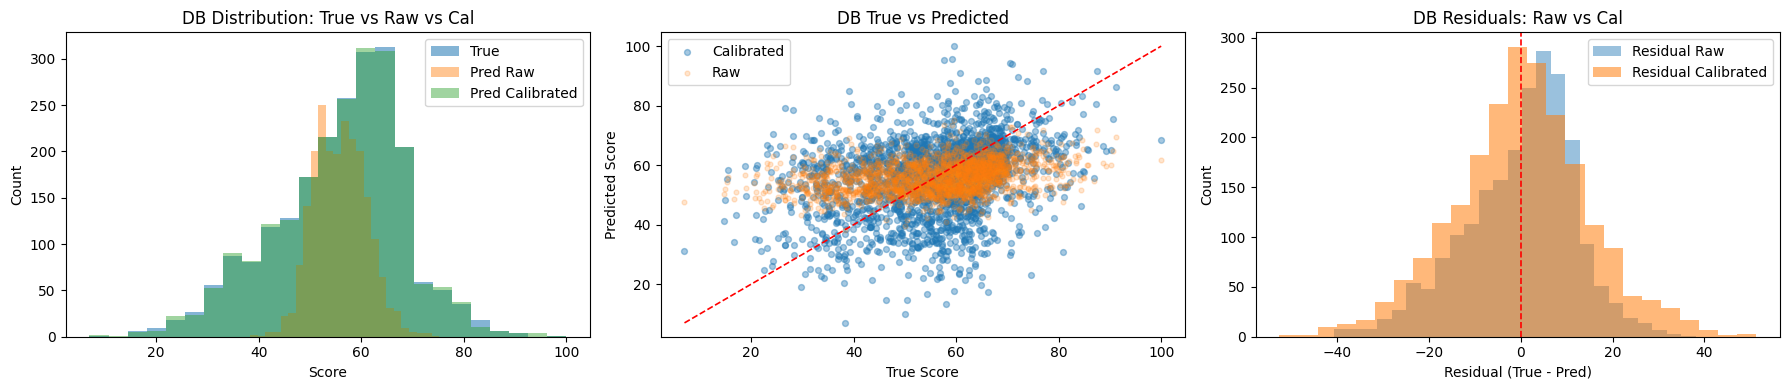

Top 10 predicted players (calibrated) — DB


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
2,201500009,Kevin Toliver II,2015,CB,0.9949,75.245094,100.000000,59.6288,T5,T3
2563,201900023,Andrew Booth,2019,CB,0.9891,73.485199,95.733026,59.1700,T5,T3
1234,201700076,Jamyest Williams,2017,CB,0.9638,73.386803,95.494458,57.7077,T5,T3
4,201500020,Kendall Sheffield,2015,CB,0.9900,72.882523,94.271800,70.4117,T5,T4
3223,202000014,Eli Ricks,2020,CB,0.9928,72.757736,93.969247,70.9303,T5,T4
1222,201700025,Richard LeCounte III,2017,S,0.9875,71.787094,91.615866,76.9391,T5,T4
1219,201700017,Shaun Wade,2017,CB,0.9903,71.778885,91.595962,87.5233,T5,T5
3822,202100018,Kool-Aid McKinstry,2021,CB,0.9906,71.559883,91.064979,60.7975,T5,T4
1220,201700018,JaCoby Stevens,2017,S,0.9901,70.972290,89.640323,72.0796,T5,T4
3823,202100029,Jason Marshall Jr.,2021,CB,0.9854,70.606918,88.754457,65.7934,T5,T4



===== EDGE Visualization Suite (Calibrated) =====


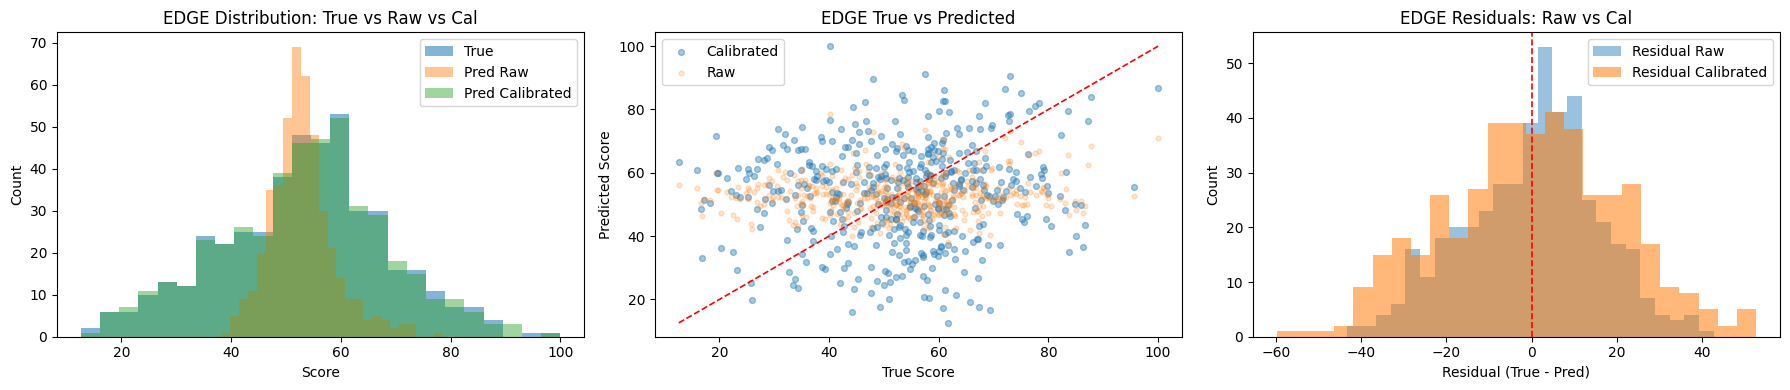

Top 10 predicted players (calibrated) — EDGE


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
6,201500057,Jalen Dalton,2015,WDE,0.9737,78.594513,100.000000,40.0965,T5,T3
0,201500003,Byron Cowart,2015,SDE,0.9987,73.652031,91.203959,57.4951,T5,T3
316,201600032,Marlon Davidson,2016,SDE,0.9812,73.349953,90.666356,72.9151,T5,T4
2147,202100059,Keanu Koht,2021,Edge,0.9715,72.790298,89.670350,48.0035,T5,T3
677,201700007,Chase Young,2017,WDE,0.9957,71.099220,86.660770,100.0000,T5,T5
1067,201800003,Xavier Thomas,2018,SDE,0.9988,70.939163,86.427350,72.1023,T5,T4
318,201600041,Shane Simmons,2016,WDE,0.9783,70.692467,86.153454,60.9284,T5,T4
1073,201800066,Ronnie Perkins,2018,WDE,0.9666,69.737175,85.092838,75.0485,T5,T4
2150,202100077,Dylan Brooks,2021,Edge,0.9658,69.249161,84.551018,53.3660,T5,T3
679,201700027,A.J. Epenesa,2017,SDE,0.9868,68.616913,83.849062,87.7959,T5,T5



===== IDL Visualization Suite (Calibrated) =====


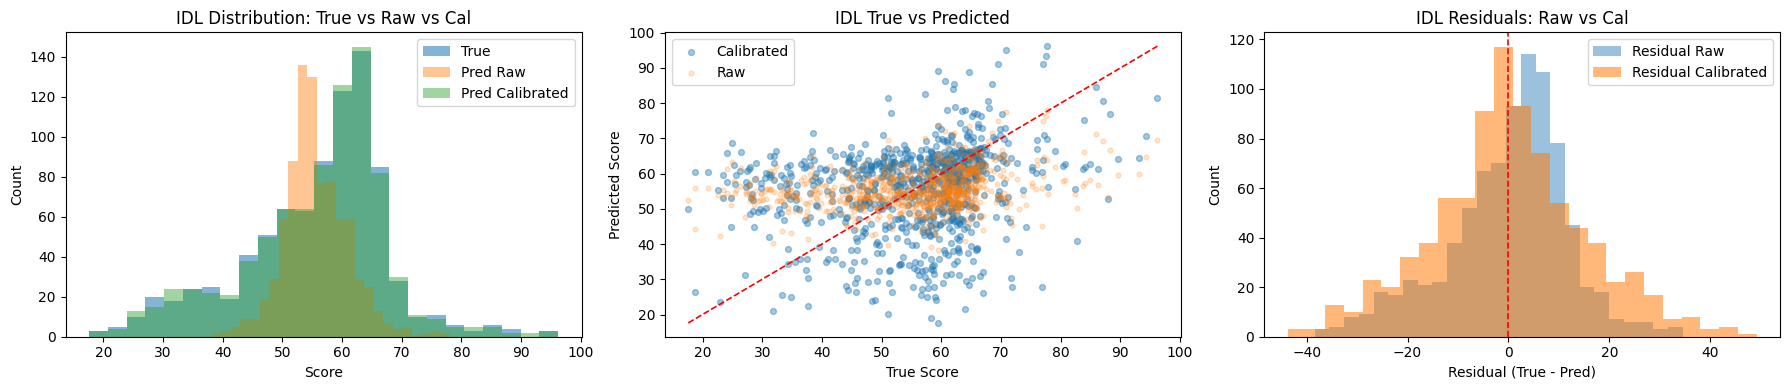

Top 10 predicted players (calibrated) — IDL


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
2,201500013,Terry Beckner Jr.,2015,DT,0.9918,78.104889,96.195500,77.6394,T5,T4
938,201900022,Travon Walker,2019,DT,0.9900,77.415878,95.049149,70.7824,T5,T4
225,201600001,Rashan Gary,2016,DT,1.0000,76.405289,93.367768,77.5369,T5,T4
226,201600002,Dexter Lawrence,2016,DT,0.9992,75.086853,91.174203,77.0945,T5,T4
457,201700006,Marvin Wilson,2017,DT,0.9957,75.022026,91.066346,69.5753,T5,T4
1178,202000008,Jordan Burch,2020,DT,0.9954,73.804123,89.040044,59.5086,T5,T3
936,201900008,Zacch Pickens,2019,DT,0.9945,73.658928,88.798474,64.6111,T5,T4
0,201500001,Trenton Thompson,2015,DT,0.9991,72.183121,86.343080,60.5670,T5,T4
1426,202100011,Leonard Taylor III,2021,DL,0.9938,71.671722,85.492234,68.5564,T5,T4
710,201800020,Taron Vincent,2018,DT,0.9884,71.637802,85.431074,62.2125,T5,T4



===== LB Visualization Suite (Calibrated) =====


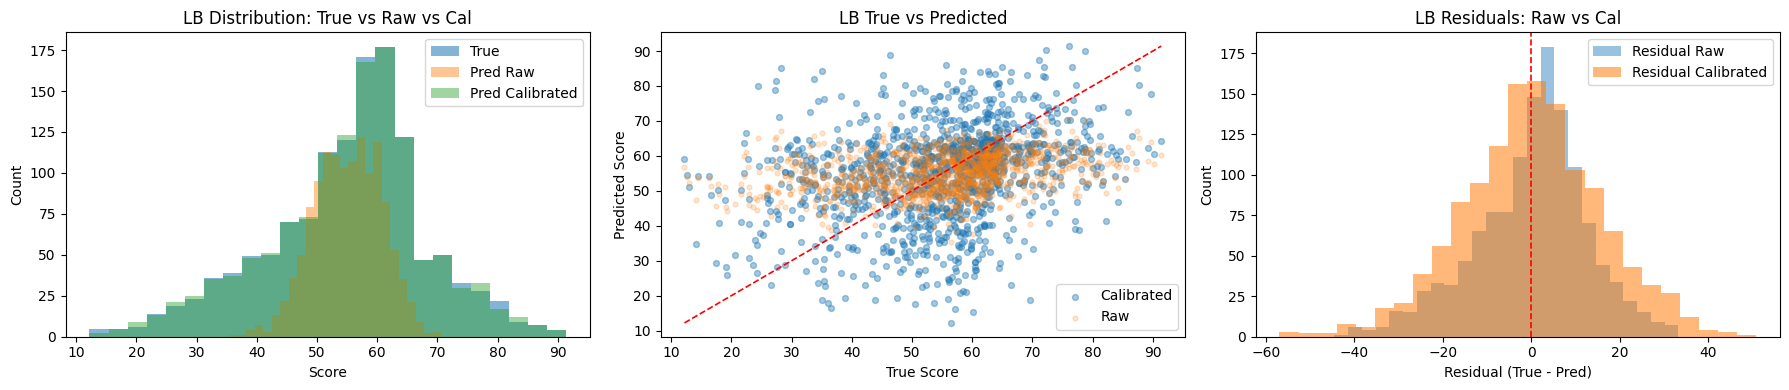

Top 10 predicted players (calibrated) — LB


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
2720,202100033,Barrett Carter,2021,LB,0.9835,70.662582,91.397600,76.1622,T5,T4
2278,202000036,Curtis Jacobs,2020,OLB,0.9823,70.008324,90.275629,72.3222,T5,T4
1797,201900025,Owen Pappoe,2019,OLB,0.9878,69.893616,90.078919,78.6829,T5,T4
394,201600011,Mique Juarez,2016,OLB,0.9924,69.116447,88.746173,46.3304,T5,T3
1806,201900110,Christian Harris,2019,ILB,0.9506,68.410789,87.536059,71.1471,T5,T4
2279,202000039,Demouy Kennedy,2020,ILB,0.9819,67.512306,85.995273,55.6431,T5,T3
431,201600400,Tyrel Dodson,2016,ILB,0.8824,67.264397,85.570139,71.8752,T5,T4
2281,202000064,Derek Wingo,2020,OLB,0.9704,67.195724,85.452375,64.9812,T5,T4
2722,202100037,Jeremiah Trotter Jr.,2021,LB,0.9818,67.179924,85.425279,76.6444,T5,T4
1796,201900019,Nakobe Dean,2019,ILB,0.9907,67.041985,85.188730,87.4416,T5,T5



===== OL Visualization Suite (Calibrated) =====


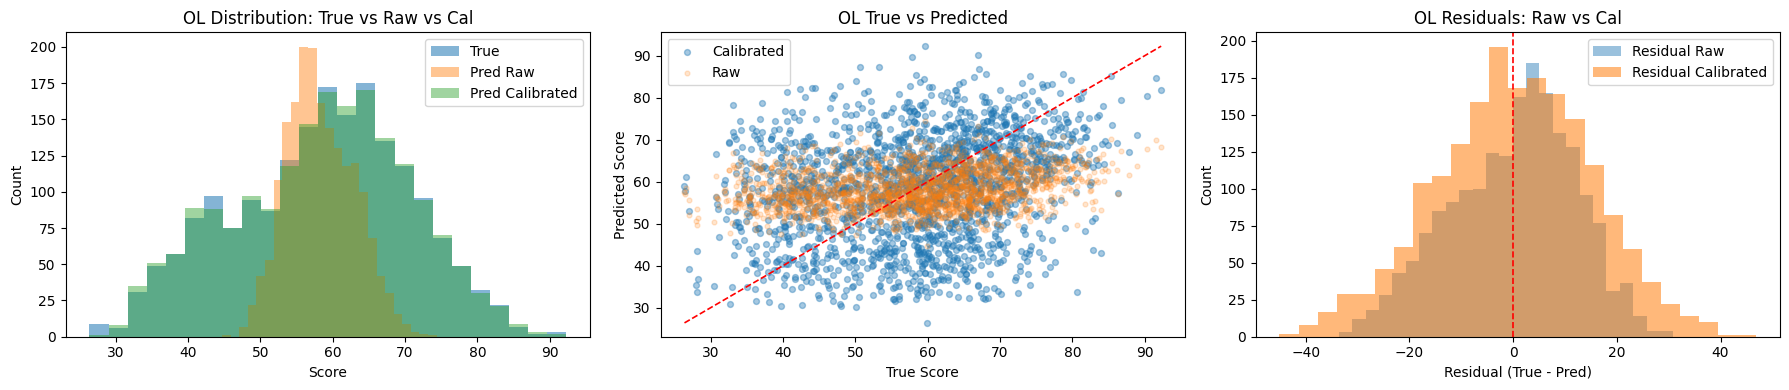

Top 10 predicted players (calibrated) — OL


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
1168,201700016,Isaiah Wilson,2017,OT,0.9904,74.355049,92.248600,59.6724,T5,T3
0,201500002,Martez Ivey,2015,OT,0.9991,73.152657,90.182908,66.9764,T5,T4
1176,201700053,Josh Myers,2017,OG,0.9757,72.787727,89.555965,57.8203,T5,T3
2454,201900552,Justin Britt,2019,OG,0.8815,71.489655,87.325896,53.2500,T5,T3
3590,202100036,Kingsley Suamataia,2021,OT,0.9823,71.480110,87.309499,50.6962,T5,T3
2973,202000038,Tate Ratledge,2020,OT,0.9821,71.182281,86.797834,67.0605,T5,T4
2974,202000048,Turner Corcoran,2020,OT,0.9748,70.562012,85.732220,78.7474,T5,T4
1175,201700048,Austin Deculus,2017,OT,0.9772,70.444244,85.529898,68.0735,T5,T4
1787,201800062,Trey Hill,2018,OG,0.9692,70.322495,85.320733,58.4461,T5,T3
1164,201700004,Alex Leatherwood,2017,OT,0.9981,70.243851,85.185625,85.2938,T5,T5



===== QB Visualization Suite (Calibrated) =====


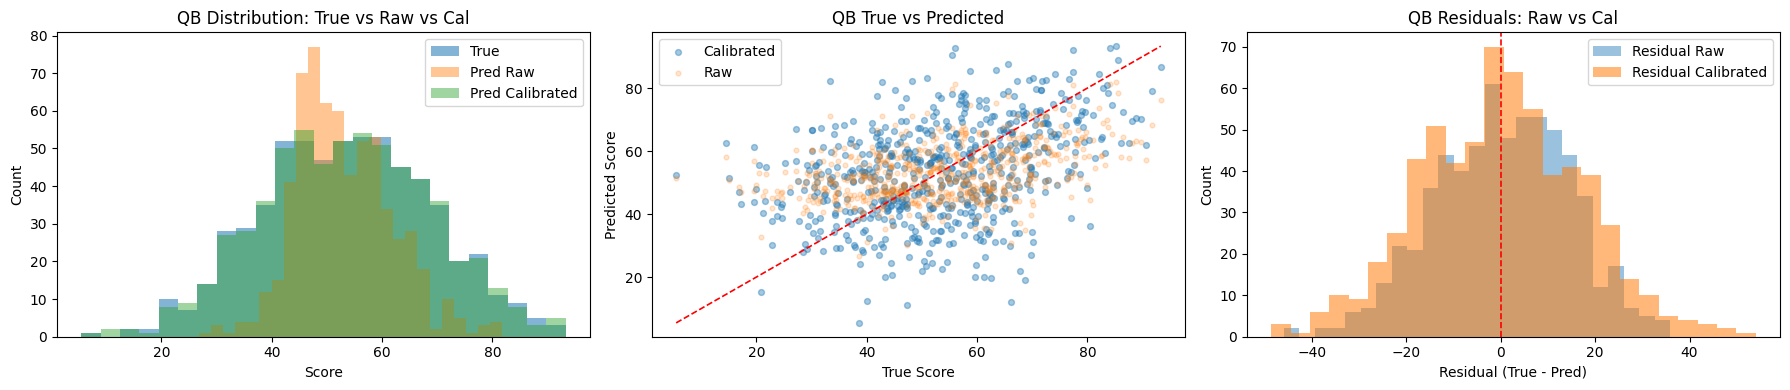

Top 10 predicted players (calibrated) — QB


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
1269,202000002,Bryce Young,2020,DUAL,0.9994,81.820702,93.307700,85.1799,T5,T5
494,201700032,Tua Tagovailoa,2017,DUAL,0.9843,81.391327,92.747754,84.1085,T5,T5
501,201700152,Myles Brennan,2017,PRO,0.9347,81.356445,92.702265,55.9476,T5,T3
1004,201900093,Sam Howell,2019,DUAL,0.9582,81.005241,92.244261,77.4371,T5,T4
1548,202100048,Jake Garcia,2021,QB,0.9761,79.614845,90.431051,55.5300,T5,T3
2,201500034,Kyler Murray,2015,DUAL,0.9854,78.552620,89.045807,85.5839,T5,T5
218,201600005,Jacob Eason,2016,PRO,0.9975,77.523666,87.703952,65.6103,T5,T4
1000,201900033,Bo Nix,2019,DUAL,0.9856,76.294922,86.585408,93.3077,T5,T5
1002,201900064,Ryan Hilinski,2019,PRO,0.9695,75.162338,85.727842,63.3846,T5,T4
1,201500022,Blake Barnett,2015,PRO,0.9898,74.702812,85.379899,58.6697,T5,T3



===== RB Visualization Suite (Calibrated) =====


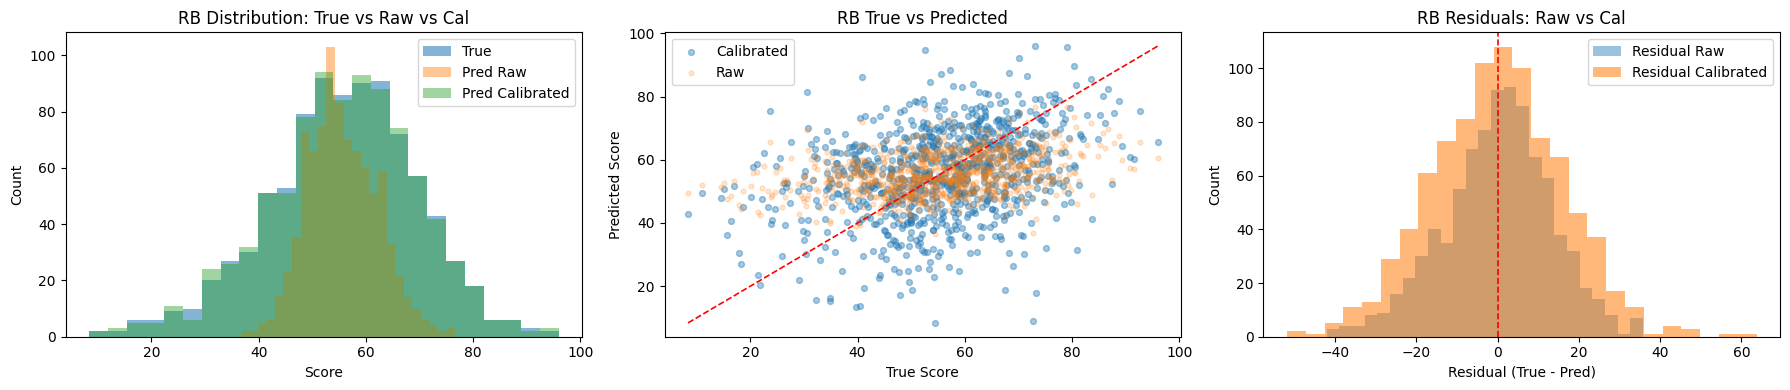

Top 10 predicted players (calibrated) — RB


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
1027,201800009,Zamir White,2018,RB,0.9957,76.681976,95.959200,73.1222,T5,T4
684,201700003,Cam Akers,2017,RB,0.9983,76.626816,95.847268,78.9931,T5,T4
1347,201900182,Sampson James,2019,RB,0.9255,76.022934,94.621869,52.6125,T5,T3
1660,202000043,MarShawn Lloyd,2020,RB,0.9778,74.811119,92.162849,70.0401,T5,T4
1659,202000040,Tank Bigsby,2020,RB,0.9814,73.583183,89.671117,80.2764,T5,T5
348,201600044,Demario McCall,2016,APB,0.9767,72.955818,88.398065,57.2162,T5,T3
685,201700020,Stephen Carr,2017,RB,0.9888,72.507927,87.489202,68.2743,T5,T4
350,201600106,Kareem Walker,2016,RB,0.9505,72.310997,87.089591,55.5273,T5,T3
346,201600029,Tavien Feaster,2016,APB,0.9816,72.103638,86.668817,71.5485,T5,T4
1658,202000020,Demarkcus Bowman,2020,RB,0.9909,71.838020,86.135332,40.8470,T5,T3



===== SPEC Visualization Suite (Calibrated) =====


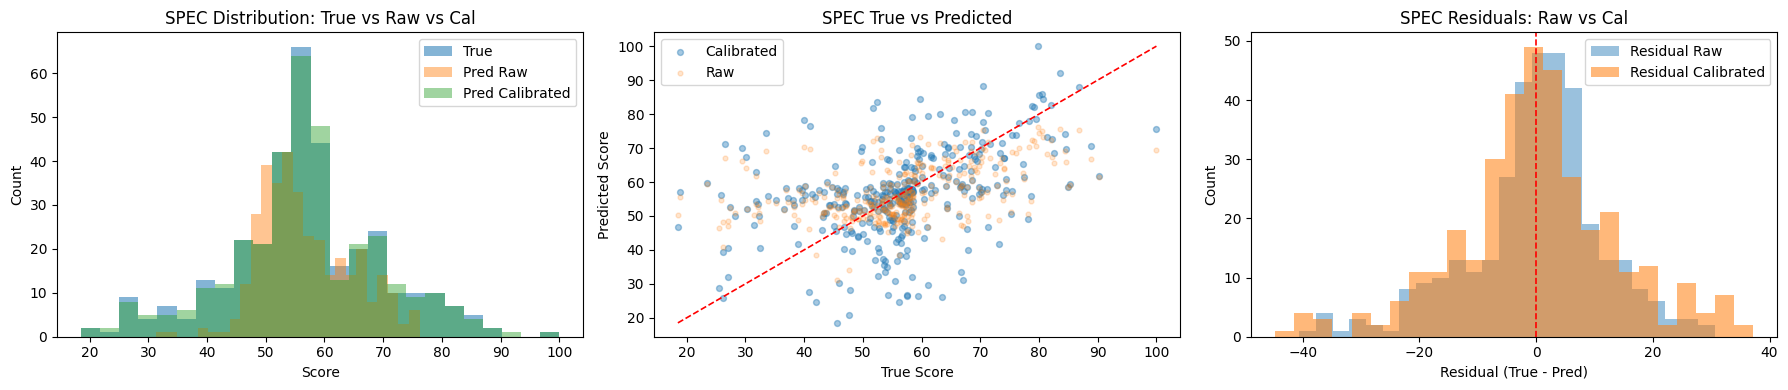

Top 10 predicted players (calibrated) — SPEC


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
466,202101533,Cam Little,2021,K,0.8378,76.190590,100.000000,79.8635,T5,T4
0,201500829,Justin Yoon,2015,K,0.8550,75.531525,91.974694,83.5944,T5,T5
396,202001718,Jack Olsen,2020,K,0.8344,75.232849,88.337782,70.3891,T5,T4
150,201701217,Anders Carlson,2017,K,0.8383,75.210167,88.061585,86.7486,T5,T5
154,201701321,Chase McGrath,2017,K,0.8333,74.873291,85.868021,80.5754,T5,T5
82,201601259,Tucker McCann,2016,K,0.8342,74.518326,85.567657,80.0000,T5,T5
90,201601579,Alex Barbir,2016,K,0.8233,73.111557,84.377277,59.7214,T5,T3
469,202101669,Andres Borregales,2021,K,0.8333,73.106857,84.373300,80.7275,T5,T5
398,202001898,Jared Zirkel,2020,K,0.8300,72.833366,83.699658,52.4560,T5,T3
306,201901335,Will Reichard,2019,K,0.8456,72.407440,82.650549,82.0929,T5,T5



===== TE Visualization Suite (Calibrated) =====


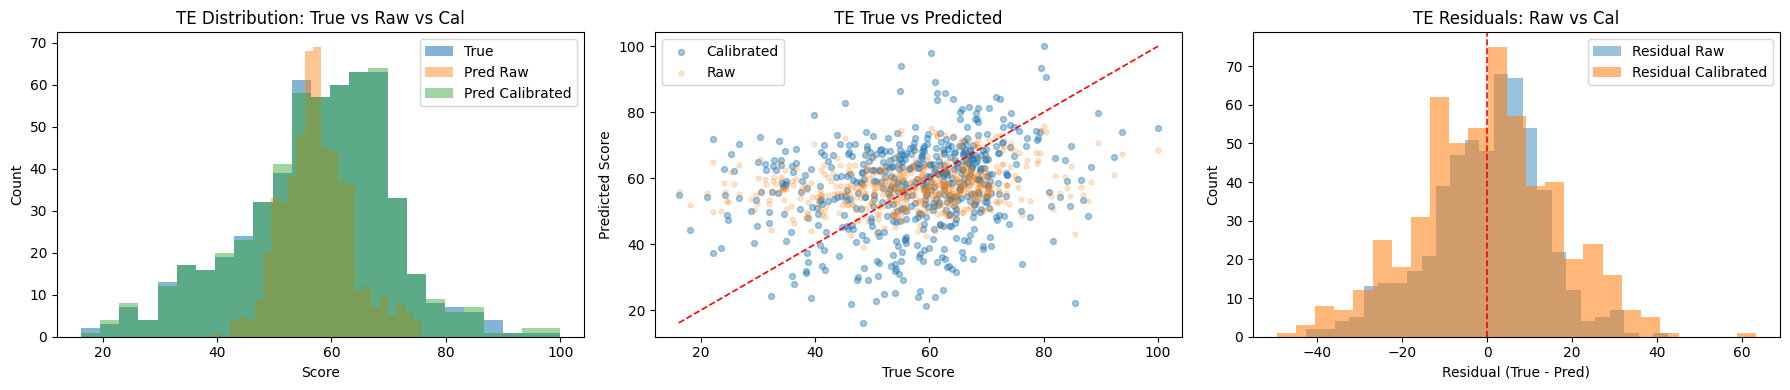

Top 10 predicted players (calibrated) — TE


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
490,201800033,Brevin Jordan,2018,TE,0.9820,75.715004,100.000000,80.1112,T5,T5
493,201800150,Zack Kuntz,2018,TE,0.9377,75.348503,97.846817,60.3421,T5,T4
150,201600150,Naseir Upshur,2016,TE,0.9341,74.687363,93.962635,54.9885,T5,T3
147,201600038,Kaden Smith,2016,TE,0.9801,74.586815,93.371919,79.5996,T5,T4
980,202100130,Michael Trigg,2021,TE,0.9402,74.146690,90.786200,80.3826,T5,T5
652,201900132,Hudson Henry,2019,TE,0.9422,73.877426,89.204280,60.9876,T5,T4
149,201600120,Jake Hausmann,2016,TE,0.9439,73.290230,86.325193,54.8544,T5,T3
649,201900053,Baylor Cupp,2019,TE,0.9731,73.190605,85.955061,61.3284,T5,T4
655,201900218,Jude Wolfe,2019,TE,0.9147,73.142426,85.776060,62.8038,T5,T4
491,201800037,Jeremy Ruckert,2018,TE,0.9810,72.847153,84.679042,71.5731,T5,T4



===== WR Visualization Suite (Calibrated) =====


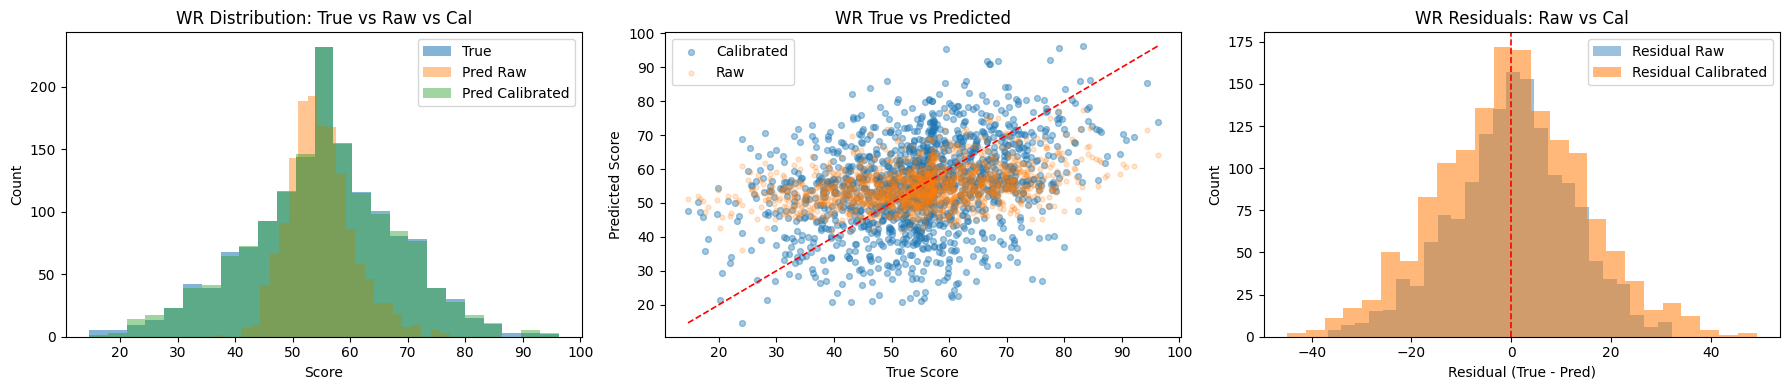

Top 10 predicted players (calibrated) — WR


,player_id,name,year,position,rating,y_pred_score_oof_raw,y_pred_score_oof_calibrated,y_true_score,y_pred_tier,y_true_tier
3,201500025,Christian Kirk,2015,WR,0.9891,77.311707,96.227400,83.2740,T5,T5
1532,201800011,Amon-Ra St. Brown,2018,WR,0.9948,76.974953,95.602242,79.1684,T5,T4
974,201700050,Tyjon Lindsey,2017,WR,0.9769,76.803047,95.283112,59.4983,T5,T3
1,201500018,Deon Cain,2015,WR,0.9906,75.164337,92.240971,77.5735,T5,T4
4,201500029,Tyron Johnson,2015,WR,0.9878,75.002991,91.941444,68.4331,T5,T4
2089,201900004,Jadon Haselwood,2019,WR,0.9966,74.973167,91.886079,66.5531,T5,T4
408,201600013,Demetris Robertson,2016,WR,0.9905,74.523224,91.050793,67.0508,T5,T4
2577,202000046,Gary Bryant Jr.,2020,WR,0.9766,74.446251,90.907898,66.8823,T5,T4
2090,201900020,Garrett Wilson,2019,WR,0.9903,72.003036,86.372256,84.4237,T5,T5
411,201600036,A.J. Brown,2016,WR,0.9803,71.852600,86.092982,82.7810,T5,T5


In [35]:
# Per-position visualization suite + top-10 predicted players (raw vs calibrated)
import matplotlib.pyplot as plt

for pos in FINAL_POSITION_GROUPS:
    pred_df = prediction_tables.get(pos)
    if pred_df is None or pred_df.empty:
        print(f"\n[{pos}] No prediction table available.")
        continue

    vis_df = pred_df.copy()
    vis_df["y_true_score"] = pd.to_numeric(vis_df.get("y_true_score", pd.NA), errors="coerce")
    vis_df["y_pred_score_oof_raw"] = pd.to_numeric(
        vis_df.get("y_pred_score_oof_raw", vis_df.get("y_pred_score_oof", pd.NA)), errors="coerce"
    )
    vis_df["y_pred_score_oof_calibrated"] = pd.to_numeric(
        vis_df.get("y_pred_score_oof_calibrated", vis_df.get("y_pred_score_oof", pd.NA)), errors="coerce"
    )
    vis_df["residual_raw"] = vis_df["y_true_score"] - vis_df["y_pred_score_oof_raw"]
    vis_df["residual_calibrated"] = vis_df["y_true_score"] - vis_df["y_pred_score_oof_calibrated"]
    vis_df = vis_df.dropna(subset=["y_true_score", "y_pred_score_oof_calibrated"]).copy()

    if vis_df.empty:
        print(f"\n[{pos}] No valid numeric prediction rows for visualization.")
        continue

    print(f"\n===== {pos} Visualization Suite (Calibrated) =====")

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].hist(vis_df["y_true_score"], bins=25, alpha=0.55, label="True")
    if vis_df["y_pred_score_oof_raw"].notna().any():
        axes[0].hist(vis_df["y_pred_score_oof_raw"], bins=25, alpha=0.45, label="Pred Raw")
    axes[0].hist(vis_df["y_pred_score_oof_calibrated"], bins=25, alpha=0.45, label="Pred Calibrated")
    axes[0].set_title(f"{pos} Distribution: True vs Raw vs Cal")
    axes[0].set_xlabel("Score")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    axes[1].scatter(vis_df["y_true_score"], vis_df["y_pred_score_oof_calibrated"], alpha=0.4, s=18, label="Calibrated")
    if vis_df["y_pred_score_oof_raw"].notna().any():
        axes[1].scatter(vis_df["y_true_score"], vis_df["y_pred_score_oof_raw"], alpha=0.2, s=12, label="Raw")
    line_min = min(
        vis_df["y_true_score"].min(),
        vis_df["y_pred_score_oof_calibrated"].min(),
        vis_df["y_pred_score_oof_raw"].min() if vis_df["y_pred_score_oof_raw"].notna().any() else vis_df["y_pred_score_oof_calibrated"].min()
    )
    line_max = max(
        vis_df["y_true_score"].max(),
        vis_df["y_pred_score_oof_calibrated"].max(),
        vis_df["y_pred_score_oof_raw"].max() if vis_df["y_pred_score_oof_raw"].notna().any() else vis_df["y_pred_score_oof_calibrated"].max()
    )
    axes[1].plot([line_min, line_max], [line_min, line_max], "r--", linewidth=1.2)
    axes[1].set_title(f"{pos} True vs Predicted")
    axes[1].set_xlabel("True Score")
    axes[1].set_ylabel("Predicted Score")
    axes[1].legend()

    if vis_df["residual_raw"].notna().any():
        axes[2].hist(vis_df["residual_raw"], bins=25, alpha=0.45, label="Residual Raw")
    axes[2].hist(vis_df["residual_calibrated"], bins=25, alpha=0.55, label="Residual Calibrated")
    axes[2].axvline(0, color="red", linestyle="--", linewidth=1.2)
    axes[2].set_title(f"{pos} Residuals: Raw vs Cal")
    axes[2].set_xlabel("Residual (True - Pred)")
    axes[2].set_ylabel("Count")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    top_cols = [
        col for col in [
            "player_id", "name", "year", "position", "rating",
            "y_pred_score_oof_raw", "y_pred_score_oof_calibrated", "y_true_score", "y_pred_tier", "y_true_tier"
        ] if col in vis_df.columns
    ]

    top10 = vis_df.sort_values("y_pred_score_oof_calibrated", ascending=False).head(10)
    print(f"Top 10 predicted players (calibrated) — {pos}")
    display(top10[top_cols])

In [47]:
import pandas as pd
import numpy as np

# 1. Combine all OOF predictions into a single Master DataFrame
all_oof_df = pd.concat(prediction_tables.values(), ignore_index=True)

# Ensure columns are numeric
all_oof_df['rating'] = pd.to_numeric(all_oof_df['rating'], errors='coerce')
all_oof_df['y_true_score'] = pd.to_numeric(all_oof_df['y_true_score'], errors='coerce')
# You can use calibrated or raw here. Raw is fine for rank correlation.
all_oof_df['y_pred'] = pd.to_numeric(all_oof_df['y_pred_score_oof_raw'], errors='coerce')

# Filter out records where we don't have all 3 pieces of data
eval_df = all_oof_df.dropna(subset=['rating', 'y_true_score', 'y_pred']).copy()

# ==========================================
# 1. CORRELATION ANALYSIS (GLOBAL & POSITION)
# ==========================================
print("--- RANK CORRELATION (SPEARMAN) ---")
print("How well did each system rank players from best to worst?\n")

global_247_rho = eval_df['rating'].corr(eval_df['y_true_score'], method='spearman')
global_model_rho = eval_df['y_pred'].corr(eval_df['y_true_score'], method='spearman')

print(f"GLOBAL 247 Rating Correlation:   {global_247_rho:.4f}")
print(f"GLOBAL XGBoost Model Correlation:{global_model_rho:.4f}")
print(f"Edge: {'Model' if global_model_rho > global_247_rho else '247Sports'} by {(global_model_rho - global_247_rho):.4f}\n")

# Per Position Breakdown
pos_records = []
for pos, group in eval_df.groupby('position_group'):
    pos_247_rho = group['rating'].corr(group['y_true_score'], method='spearman')
    pos_model_rho = group['y_pred'].corr(group['y_true_score'], method='spearman')
    
    pos_records.append({
        'Position': pos,
        'N_Players': len(group),
        '247_Spearman': round(pos_247_rho, 4),
        'Model_Spearman': round(pos_model_rho, 4),
        'Model_Advantage': round(pos_model_rho - pos_247_rho, 4)
    })

df_pos_eval = pd.DataFrame(pos_records).sort_values('Model_Advantage', ascending=False)
display(df_pos_eval)

# ==========================================
# 2. THE "TOP PROSPECT" SIMULATION
# ==========================================
print("\n--- TOP PROSPECT EVALUATION ---")
print("If you only recruited the Top 10% of players based on each system,")
print("whose recruiting class actually produced more value on the field?\n")

top_10_percent_cutoff = int(len(eval_df) * 0.10)

# Sort by 247 Rating to simulate 247's "Top Class"
top_247_class = eval_df.sort_values('rating', ascending=False).head(top_10_percent_cutoff)

# Sort by Model Prediction to simulate the Model's "Top Class"
top_model_class = eval_df.sort_values('y_pred', ascending=False).head(top_10_percent_cutoff)

avg_true_score_247 = top_247_class['y_true_score'].mean()
avg_true_score_model = top_model_class['y_true_score'].mean()

print(f"Average True Score of 247's Top {top_10_percent_cutoff} players:    {avg_true_score_247:.2f}")
print(f"Average True Score of Model's Top {top_10_percent_cutoff} players:  {avg_true_score_model:.2f}")

if avg_true_score_model > avg_true_score_247:
    diff = avg_true_score_model - avg_true_score_247
    print(f"\n✅ The XGBoost Model successfully identified better elite talent than 247Sports (+{diff:.2f} score advantage per player).")
else:
    diff = avg_true_score_247 - avg_true_score_model
    print(f"\n❌ 247Sports is still better at identifying elite talent than the Model (+{diff:.2f} score advantage per player).")
    


--- RANK CORRELATION (SPEARMAN) ---
How well did each system rank players from best to worst?

GLOBAL 247 Rating Correlation:   0.3166
GLOBAL XGBoost Model Correlation:0.3261
Edge: Model by 0.0095



,Position,N_Players,247_Spearman,Model_Spearman,Model_Advantage
7,SPEC,351,0.3525,0.4795,0.1270
3,LB,1291,0.3387,0.3274,-0.0113
9,WR,1495,0.3486,0.3322,-0.0164
4,OL,1886,0.2837,0.2592,-0.0245
0,DB,2176,0.3648,0.3397,-0.0251
6,RB,888,0.3721,0.3264,-0.0457
5,QB,629,0.4405,0.3829,-0.0576
2,IDL,853,0.3519,0.2795,-0.0724
1,EDGE,453,0.1668,0.0569,-0.1099
8,TE,556,0.3691,0.2255,-0.1437



--- TOP PROSPECT EVALUATION ---
If you only recruited the Top 10% of players based on each system,
whose recruiting class actually produced more value on the field?

Average True Score of 247's Top 1057 players:    64.54
Average True Score of Model's Top 1057 players:  64.06

❌ 247Sports is still better at identifying elite talent than the Model (+0.48 score advantage per player).


In [61]:
import pandas as pd

# 1. Combine all OOF prediction dataframes into one
all_oof_df = pd.concat(prediction_tables.values(), ignore_index=True)

# 2. Extract and clean the two columns we want to compare
# Using the calibrated score, but you can swap to 'y_pred_score_oof_raw' if you prefer
rating_col = pd.to_numeric(all_oof_df['rating'], errors='coerce')
pred_col = pd.to_numeric(all_oof_df['y_pred_score_oof_calibrated'], errors='coerce')

# 3. Create a clean subset dropping any rows missing either value
corr_df = pd.DataFrame({
    '247_Rating': rating_col, 
    'Model_Prediction': pred_col
}).dropna()

# 4. Calculate Correlations
pearson_corr = corr_df['247_Rating'].corr(corr_df['Model_Prediction'], method='pearson')
spearman_corr = corr_df['247_Rating'].corr(corr_df['Model_Prediction'], method='spearman')

print("--- Agreement: 247Sports Rating vs. XGBoost Prediction ---")
print(f"Sample Size: {len(corr_df)} players\n")
print(f"Pearson Correlation (Linear): {pearson_corr:.4f}")
print(f"Spearman Correlation (Rank):  {spearman_corr:.4f}")

# Optional: Quick Positional Breakdown
print("\n--- Spearman Correlation by Position ---")
for pos, group in all_oof_df.dropna(subset=['rating', 'y_pred_score_oof_calibrated']).groupby('position_group'):
    pos_corr = pd.to_numeric(group['rating']).corr(pd.to_numeric(group['y_pred_score_oof_calibrated']), method='spearman')
    print(f"{pos.ljust(5)}: {pos_corr:.4f}")

--- Agreement: 247Sports Rating vs. XGBoost Prediction ---
Sample Size: 10578 players

Pearson Correlation (Linear): 0.7033
Spearman Correlation (Rank):  0.7264

--- Spearman Correlation by Position ---
DB   : 0.8579
EDGE : 0.3939
IDL  : 0.6900
LB   : 0.7657
OL   : 0.7395
QB   : 0.8098
RB   : 0.7808
SPEC : 0.5928
TE   : 0.7800
WR   : 0.7900


In [40]:
# Quick artifact inventory
artifacts = sorted(MODEL_DIR.glob("*"))
print(f"Total artifacts in {MODEL_DIR}: {len(artifacts)}")
for p in artifacts:
    print(p.name)

Total artifacts in x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final\models\xgboost_positional: 100
DB_cv_class_fold_metrics.csv
DB_cv_fold_metrics.csv
DB_future_class_predictions_2022_2028.csv
DB_future_predictions_2022_2028.csv
DB_oof_class_predictions.csv
DB_oof_predictions.csv
DB_test_predictions.csv
DB_xgb_classifier.joblib
DB_xgb_regressor.joblib
EDGE_cv_class_fold_metrics.csv
EDGE_cv_fold_metrics.csv
EDGE_future_class_predictions_2022_2028.csv
EDGE_future_predictions_2022_2028.csv
EDGE_oof_class_predictions.csv
EDGE_oof_predictions.csv
EDGE_test_predictions.csv
EDGE_xgb_classifier.joblib
EDGE_xgb_regressor.joblib
IDL_cv_class_fold_metrics.csv
IDL_cv_fold_metrics.csv
IDL_future_class_predictions_2022_2028.csv
IDL_future_predictions_2022_2028.csv
IDL_oof_class_predictions.csv
IDL_oof_predictions.csv
IDL_test_predictions.csv
IDL_xgb_classifier.joblib
IDL_xgb_regressor.joblib
LB_cv_class_fold_metrics.csv
LB_cv_fold_metrics.csv
LB_fut

In [44]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    log_loss, roc_auc_score, accuracy_score, f1_score, brier_score_loss
 )
from sklearn.model_selection import StratifiedKFold, ParameterSampler
from sklearn.pipeline import Pipeline

param_space_cls = {
    "model__n_estimators": [150, 250, 400],
    "model__max_depth": [3, 4, 6],
    "model__learning_rate": [0.03, 0.05, 0.08],
    "model__subsample": [0.75, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_lambda": [1.0, 2.0, 4.0],
}

class_model_rows = []
class_feature_rows = []
class_prediction_tables = {}
class_future_prediction_tables = {}
class_feature_inventory_rows = []

for pos in FINAL_POSITION_GROUPS:
    df = datasets[pos].copy()

    target_numeric = pd.to_numeric(df.get("target_career_score_0_100", pd.NA), errors="coerce")
    valid_target_mask = target_numeric.notna()
    df = df[valid_target_mask].copy()
    target_numeric = pd.to_numeric(df["target_career_score_0_100"], errors="coerce")
    df["target_binary"] = (target_numeric >= 20.0).astype(int)

    if len(df) < 80:
        print(f"Skipping {pos}: not enough rows for 5-fold CV ({len(df)})")
        continue

    candidate_cols = select_model_feature_candidates(df)
    numeric_cols, categorical_cols, dropped_cols = infer_column_types(df, candidate_cols)
    model_feature_cols = numeric_cols + categorical_cols

    if len(model_feature_cols) < 5:
        print(f"Skipping {pos}: too few modeled features ({len(model_feature_cols)})")
        continue

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    X_all = df[model_feature_cols].copy()
    y_all = df["target_binary"].copy()
    df_valid = df.loc[X_all.index].copy()

    if y_all.nunique() < 2:
        print(f"Skipping {pos}: only one class present")
        continue

    preprocessor = build_preprocessor(numeric_cols, categorical_cols)
    sampled_params = list(ParameterSampler(param_space_cls, n_iter=N_TUNING_ITER, random_state=SEED))
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    best_logloss = float("inf")
    best_params = None

    for params in sampled_params:
        fold_loglosses = []
        for train_idx, val_idx in skf.split(X_all, y_all):
            X_train, y_train = X_all.iloc[train_idx], y_all.iloc[train_idx]
            X_val, y_val = X_all.iloc[val_idx], y_all.iloc[val_idx]

            pipe = Pipeline(steps=[
                ("prep", preprocessor),
                ("model", XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",
                    tree_method=XGB_TREE_METHOD,
                    device=XGB_DEVICE,
                    random_state=SEED,
                    n_jobs=-1,
                )),
            ])
            pipe.set_params(**params)
            pipe.fit(X_train, y_train)
            val_pred_proba = np.clip(pipe.predict_proba(X_val)[:, 1], 1e-6, 1 - 1e-6)
            fold_loglosses.append(log_loss(y_val, val_pred_proba))

        mean_fold_logloss = float(np.mean(fold_loglosses))
        if mean_fold_logloss < best_logloss:
            best_logloss = mean_fold_logloss
            best_params = params

    oof_pred_proba_raw = pd.Series(index=X_all.index, dtype=float)
    oof_fold_rows = []

    for fold_id, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), start=1):
        X_train, y_train = X_all.iloc[train_idx], y_all.iloc[train_idx]
        X_val, y_val = X_all.iloc[val_idx], y_all.iloc[val_idx]

        fold_pipe = Pipeline(steps=[
            ("prep", preprocessor),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method=XGB_TREE_METHOD,
                device=XGB_DEVICE,
                random_state=SEED,
                n_jobs=-1,
            )),
        ])
        if best_params:
            fold_pipe.set_params(**best_params)

        fold_pipe.fit(X_train, y_train)
        val_pred_proba = np.clip(fold_pipe.predict_proba(X_val)[:, 1], 1e-6, 1 - 1e-6)
        val_pred_class = (val_pred_proba >= 0.5).astype(int)
        oof_pred_proba_raw.iloc[val_idx] = val_pred_proba

        fold_auc = roc_auc_score(y_val, val_pred_proba) if y_val.nunique() > 1 else np.nan
        oof_fold_rows.append({
            "position": pos,
            "fold": fold_id,
            "rows_val": len(val_idx),
            "fold_accuracy": float(accuracy_score(y_val, val_pred_class)),
            "fold_roc_auc": float(fold_auc) if pd.notna(fold_auc) else np.nan,
            "fold_f1": float(f1_score(y_val, val_pred_class, zero_division=0)),
            "fold_logloss": float(log_loss(y_val, val_pred_proba)),
            "fold_brier": float(brier_score_loss(y_val, val_pred_proba)),
        })

    final_pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method=XGB_TREE_METHOD,
            device=XGB_DEVICE,
            random_state=SEED,
            n_jobs=-1,
        )),
    ])
    if best_params:
        final_pipe.set_params(**best_params)
    final_pipe.fit(X_all, y_all)

    oof_pred_class_raw = (oof_pred_proba_raw >= 0.5).astype(int)
    oof_auc_raw = roc_auc_score(y_all, oof_pred_proba_raw) if y_all.nunique() > 1 else np.nan

    oof_metrics = {
        "oof_logloss_raw": float(log_loss(y_all, oof_pred_proba_raw)),
        "oof_brier_raw": float(brier_score_loss(y_all, oof_pred_proba_raw)),
        "oof_accuracy_raw": float(accuracy_score(y_all, oof_pred_class_raw)),
        "oof_f1_raw": float(f1_score(y_all, oof_pred_class_raw, zero_division=0)),
        "oof_auc_raw": float(oof_auc_raw) if pd.notna(oof_auc_raw) else np.nan,
    }

    model_path = MODEL_DIR / f"{pos}_xgb_classifier.joblib"
    joblib.dump({
        "position": pos,
        "pipeline": final_pipe,
        "feature_columns": model_feature_cols,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "best_params": best_params,
        "cv": {"n_folds": N_FOLDS, "strategy": "StratifiedKFold"},
        "target": "target_binary (target_career_score_0_100 >= 20)",
        "future_year_window": {"min": PREDICT_YEAR_MIN, "max": PREDICT_YEAR_MAX},
    }, model_path)

    pred_out = df_valid.loc[X_all.index, [c for c in ["player_id", "name", "year", "position", "rating", "target_career_score_0_100"] if c in df_valid.columns]].copy()
    pred_out["y_true_binary"] = y_all.values
    pred_out["y_pred_prob_raw"] = oof_pred_proba_raw.values
    pred_out["y_pred_class_raw"] = oof_pred_class_raw.values
    pred_out["position_group"] = pos

    pred_path = MODEL_DIR / f"{pos}_oof_class_predictions.csv"
    pred_out.to_csv(pred_path, index=False, encoding="utf-8-sig")
    class_prediction_tables[pos] = pred_out

    future_pred_path = ""
    future_df = inference_datasets.get(pos, pd.DataFrame()).copy()
    if not future_df.empty:
        for col in model_feature_cols:
            if col not in future_df.columns:
                future_df[col] = np.nan
        for col in numeric_cols:
            future_df[col] = pd.to_numeric(future_df[col], errors="coerce")

        X_future = future_df[model_feature_cols].copy()
        future_prob_raw = np.clip(final_pipe.predict_proba(X_future)[:, 1], 1e-6, 1 - 1e-6)
        future_odds_raw = future_prob_raw / (1.0 - future_prob_raw)

        future_out = future_df[[c for c in ["player_id", "name", "year", "position", "rating"] if c in future_df.columns]].copy()
        future_out["position_group"] = pos
        future_out["contrib_prob_raw"] = future_prob_raw
        future_out["contrib_odds_raw"] = future_odds_raw

        future_pred_path = MODEL_DIR / f"{pos}_future_class_predictions_{PREDICT_YEAR_MIN}_{PREDICT_YEAR_MAX}.csv"
        future_out.to_csv(future_pred_path, index=False, encoding="utf-8-sig")
        class_future_prediction_tables[pos] = future_out

    fold_metrics_df = pd.DataFrame(oof_fold_rows)
    fold_metrics_path = MODEL_DIR / f"{pos}_cv_class_fold_metrics.csv"
    fold_metrics_df.to_csv(fold_metrics_path, index=False, encoding="utf-8-sig")

    fitted_prep = final_pipe.named_steps["prep"]
    fitted_model = final_pipe.named_steps["model"]
    feat_names = get_feature_names(fitted_prep)
    importances = getattr(fitted_model, "feature_importances_", None)

    if importances is not None and len(feat_names) == len(importances):
        fi_df = pd.DataFrame({
            "feature": feat_names,
            "importance": importances,
            "position": pos
        }).sort_values("importance", ascending=False).head(30)
        class_feature_rows.append(fi_df)

    class_feature_inventory_rows.append({
        "position": pos,
        "n_features": len(model_feature_cols),
        "feature_list": " | ".join(model_feature_cols),
    })

    class_model_rows.append({
        "position": pos,
        "rows_total": len(df_valid),
        "rows_modeled": len(X_all),
        "rows_future_2022_2028": len(inference_datasets.get(pos, pd.DataFrame())),
        "class_1_ratio": round(float(y_all.mean()), 4),
        "cv_strategy": f"StratifiedKFold({N_FOLDS})",
        "cv_logloss_bestparam": round(float(best_logloss), 4),
        "oof_logloss_raw": round(oof_metrics["oof_logloss_raw"], 4),
        "oof_brier_raw": round(oof_metrics["oof_brier_raw"], 4),
        "oof_auc_raw": round(oof_metrics["oof_auc_raw"], 4) if pd.notna(oof_metrics["oof_auc_raw"]) else np.nan,
        "oof_f1_raw": round(oof_metrics["oof_f1_raw"], 4),
        "best_params": json.dumps(best_params, sort_keys=True),
        "model_path": str(model_path),
        "pred_path": str(pred_path),
        "future_pred_path": str(future_pred_path),
        "fold_metrics_path": str(fold_metrics_path),
    })

    auc_raw_str = f"{oof_metrics['oof_auc_raw']:.4f}" if pd.notna(oof_metrics['oof_auc_raw']) else "nan"
    print(f"[{pos}] class done | cv_logloss={best_logloss:.4f} | auc_raw={auc_raw_str}")

class_metrics_df = pd.DataFrame(class_model_rows).sort_values("position")
class_metrics_path = MODEL_DIR / "xgb_classification_metrics_summary.csv"
class_metrics_df.to_csv(class_metrics_path, index=False, encoding="utf-8-sig")

class_feature_inventory_df = pd.DataFrame(class_feature_inventory_rows).sort_values("position")
class_feature_inventory_path = MODEL_DIR / "xgb_class_feature_inventory.csv"
class_feature_inventory_df.to_csv(class_feature_inventory_path, index=False, encoding="utf-8-sig")

if class_feature_rows:
    class_feature_importance_df = pd.concat(class_feature_rows, ignore_index=True)
    class_feature_importance_path = MODEL_DIR / "xgb_class_top_feature_importance.csv"
    class_feature_importance_df.to_csv(class_feature_importance_path, index=False, encoding="utf-8-sig")

class_all_future_path = MODEL_DIR / f"xgb_class_all_positions_predictions_{PREDICT_YEAR_MIN}_{PREDICT_YEAR_MAX}_raw.csv"
if class_future_prediction_tables:
    class_all_future_df = pd.concat(class_future_prediction_tables.values(), ignore_index=True)
    class_all_future_df["contrib_prob_raw"] = pd.to_numeric(class_all_future_df["contrib_prob_raw"], errors="coerce").clip(0.0, 1.0)
    class_all_future_df["contrib_odds_raw"] = class_all_future_df["contrib_prob_raw"] / (1.0 - class_all_future_df["contrib_prob_raw"].clip(upper=1 - 1e-6))
    class_all_future_df.to_csv(class_all_future_path, index=False, encoding="utf-8-sig")

print(f"\nSaved classification metrics summary: {class_metrics_path}")
print(f"Saved classification feature inventory: {class_feature_inventory_path}")
if class_feature_rows:
    print(f"Saved classification feature importance: {class_feature_importance_path}")
if class_future_prediction_tables:
    print(f"Saved all-position class future predictions: {class_all_future_path}")

display(class_metrics_df)
display(class_feature_inventory_df)

[DB] class done | cv_logloss=0.4538 | auc_raw=0.6265
[EDGE] class done | cv_logloss=0.5727 | auc_raw=0.6519
[IDL] class done | cv_logloss=0.4924 | auc_raw=0.6251
[LB] class done | cv_logloss=0.5179 | auc_raw=0.6545
[OL] class done | cv_logloss=0.5935 | auc_raw=0.6230
[QB] class done | cv_logloss=0.5728 | auc_raw=0.7013
[RB] class done | cv_logloss=0.4981 | auc_raw=0.6066
[SPEC] class done | cv_logloss=0.4756 | auc_raw=0.5990
[TE] class done | cv_logloss=0.5650 | auc_raw=0.5768
[WR] class done | cv_logloss=0.4953 | auc_raw=0.6614

Saved classification metrics summary: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final\models\xgboost_positional\xgb_classification_metrics_summary.csv
Saved classification feature inventory: x:\My Files\Courses\DSBA 6010 - LLM\Project\Code\Gridiron_Intelligence\data\modeling_datasets\final\models\xgboost_positional\xgb_class_feature_inventory.csv
Saved classification feature importance: x:\My Files\Courses\DS

,position,rows_total,rows_modeled,rows_future_2022_2028,class_1_ratio,cv_strategy,cv_logloss_bestparam,oof_logloss_raw,oof_brier_raw,oof_auc_raw,oof_f1_raw,best_params,model_path,pred_path,future_pred_path,fold_metrics_path
0,DB,2622,2622,2537,0.8265,StratifiedKFold(5),0.4538,0.4538,0.1424,0.6265,0.9033,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
1,EDGE,613,613,1111,0.7243,StratifiedKFold(5),0.5727,0.5727,0.1961,0.6519,0.8138,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
2,IDL,1062,1062,1544,0.8004,StratifiedKFold(5),0.4924,0.4923,0.1596,0.6251,0.8810,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
3,LB,1666,1666,1435,0.7671,StratifiedKFold(5),0.5179,0.5179,0.1697,0.6545,0.8641,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
4,OL,2690,2690,2622,0.7011,StratifiedKFold(5),0.5935,0.5935,0.2038,0.6230,0.8057,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
5,QB,914,914,1080,0.6794,StratifiedKFold(5),0.5728,0.5728,0.1966,0.7013,0.7917,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
6,RB,1088,1088,1037,0.8070,StratifiedKFold(5),0.4981,0.4981,0.1583,0.6066,0.8836,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
7,SPEC,424,424,217,0.8231,StratifiedKFold(5),0.4756,0.4756,0.1480,0.5990,0.9008,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
8,TE,725,725,831,0.7641,StratifiedKFold(5),0.5650,0.5650,0.1864,0.5768,0.8530,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...
9,WR,1897,1897,1978,0.7839,StratifiedKFold(5),0.4953,0.4953,0.1619,0.6614,0.8760,"{""model__colsample_bytree"": 0.7, ""model__learn...",x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...,x:\My Files\Courses\DSBA 6010 - LLM\Project\Co...


,position,n_features,feature_list
0,DB,23,height_inches | weight_lbs | rating | skill_Si...
1,EDGE,23,height_inches | weight_lbs | rating | skill_Fi...
2,IDL,23,height_inches | weight_lbs | rating | skill_Fi...
3,LB,23,height_inches | weight_lbs | rating | skill_At...
4,OL,23,height_inches | weight_lbs | rating | skill_St...
5,QB,23,height_inches | weight_lbs | rating | skill_Si...
6,RB,23,height_inches | weight_lbs | rating | skill_Ex...
7,SPEC,13,height_inches | weight_lbs | rating | state | ...
8,TE,23,height_inches | weight_lbs | rating | skill_Po...
9,WR,23,height_inches | weight_lbs | rating | skill_St...



===== DB Classifier Diagnostics (Raw) =====


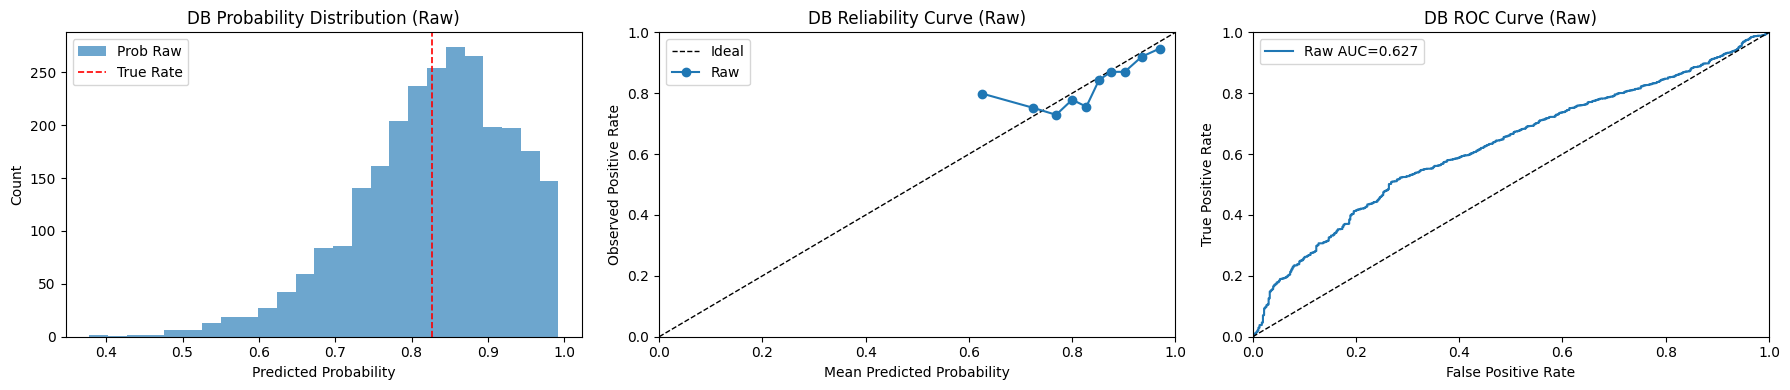

Top 10 contribution probability (raw) — DB


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
1943,201800064,Anthony Cook,2018,CB,0.9682,0.992322,1,70.7768
1945,201800071,Josh Proctor,2018,S,0.9640,0.990788,1,68.6475
2568,201900045,Lewis Cine,2019,S,0.9765,0.990121,1,64.0867
1931,201800021,Tyreke Johnson,2018,S,0.9876,0.989861,1,49.1978
6,201500044,Deionte Thompson,2015,S,0.9806,0.989513,1,75.6096
3227,202000035,Demorie Tate,2020,CB,0.9828,0.989308,0,0.0
2599,201900192,Chris Adimora,2019,S,0.9218,0.988612,1,65.0633
2595,201900164,Jeremiah Criddell,2019,S,0.9326,0.987187,1,50.1323
1934,201800032,Isaac Taylor-Stuart,2018,CB,0.9827,0.986657,1,58.414
3828,202100072,Nyland Green,2021,CB,0.9682,0.985642,1,67.105



===== EDGE Classifier Diagnostics (Raw) =====


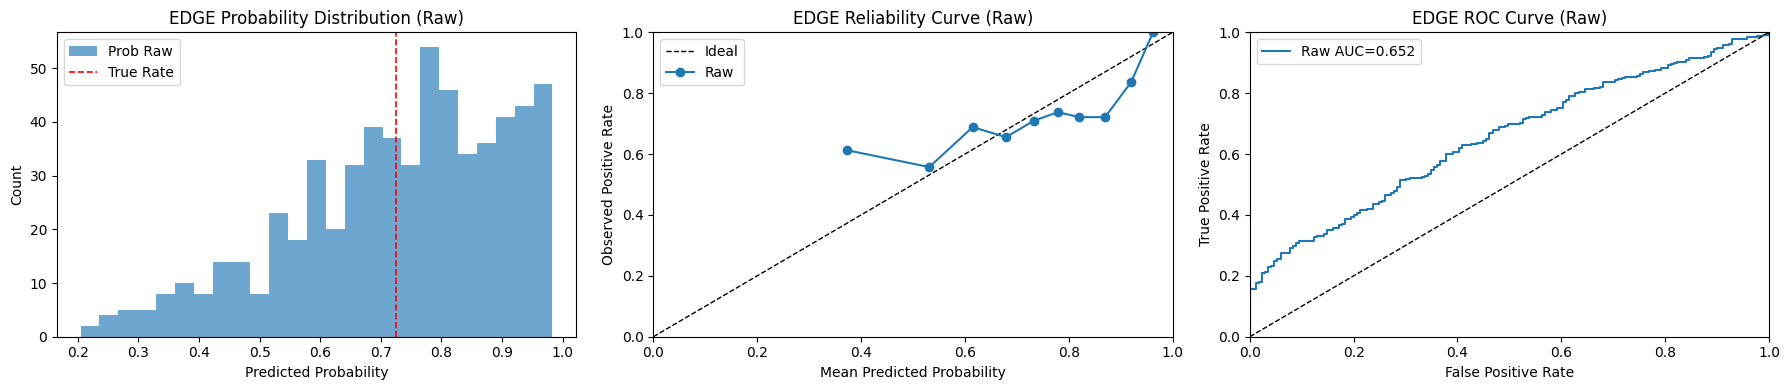

Top 10 contribution probability (raw) — EDGE


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
691,201700167,Jordan Williams,2017,WDE,0.9299,0.983171,1,40.1214
679,201700027,A.J. Epenesa,2017,SDE,0.9868,0.982840,1,87.7959
1817,202000007,Myles Murphy,2020,SDE,0.9965,0.981839,1,77.4651
1082,201800142,Justin Mascoll,2018,WDE,0.9412,0.980692,1,62.3256
7,201500065,Jonathan Ledbetter,2015,SDE,0.9680,0.979332,1,61.0535
325,201600102,Auston Robertson,2016,WDE,0.9521,0.978666,1,38.5664
686,201700128,Addison Gumbs,2017,WDE,0.9407,0.975443,1,32.3989
692,201700175,Jake Lawler,2017,WDE,0.9277,0.975283,1,25.1632
694,201700197,Yetur Gross-Matos,2017,SDE,0.9223,0.975233,1,83.2674
1833,202000177,Van Fillinger,2020,SDE,0.9276,0.973586,1,76.1175



===== IDL Classifier Diagnostics (Raw) =====


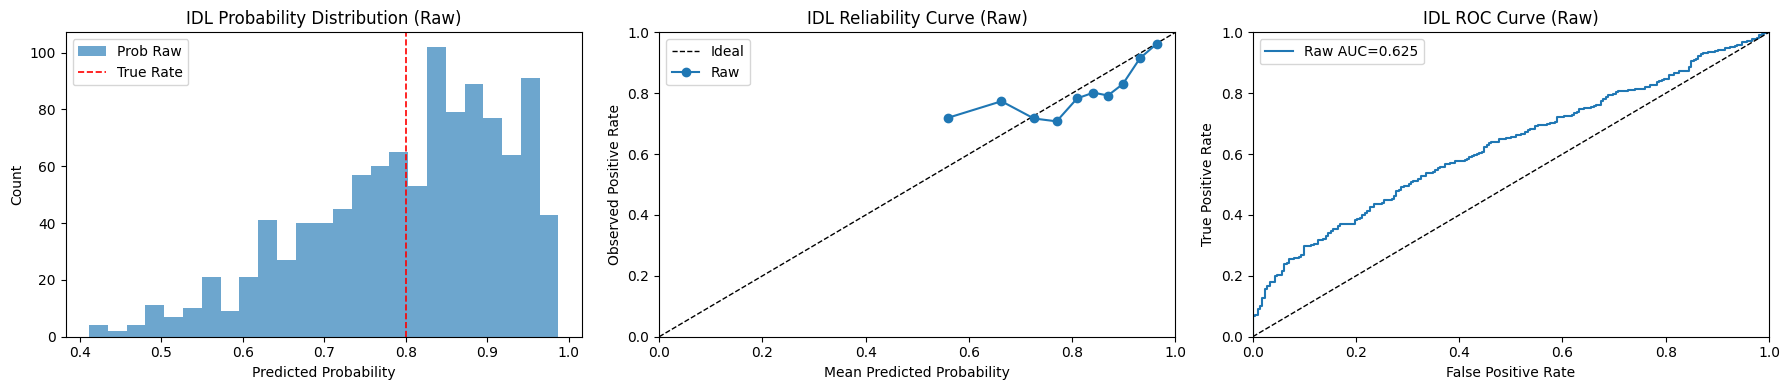

Top 10 contribution probability (raw) — IDL


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
461,201700060,Marlon Tuipulotu,2017,DT,0.9720,0.987303,1,69.904
462,201700068,Haskell Garrett,2017,DT,0.9678,0.985660,1,66.3884
1428,202100022,Shemar Turner,2021,DL,0.9877,0.983302,1,71.1385
711,201800054,Nesta Jade Silvera,2018,DT,0.9730,0.981040,1,63.9221
1423,202100002,Korey Foreman,2021,DL,0.9992,0.980473,1,57.2233
460,201700054,Tyler Shelvin,2017,DT,0.9754,0.980169,1,51.142
225,201600001,Rashan Gary,2016,DT,1.0000,0.980029,1,77.5369
459,201700039,Jay Tufele,2017,DT,0.9817,0.979892,1,70.4798
1439,202100117,Gabriel Rubio,2021,DL,0.9472,0.979888,1,61.7666
712,201800055,Tommy Togiai,2018,DT,0.9721,0.979642,1,59.9642



===== LB Classifier Diagnostics (Raw) =====


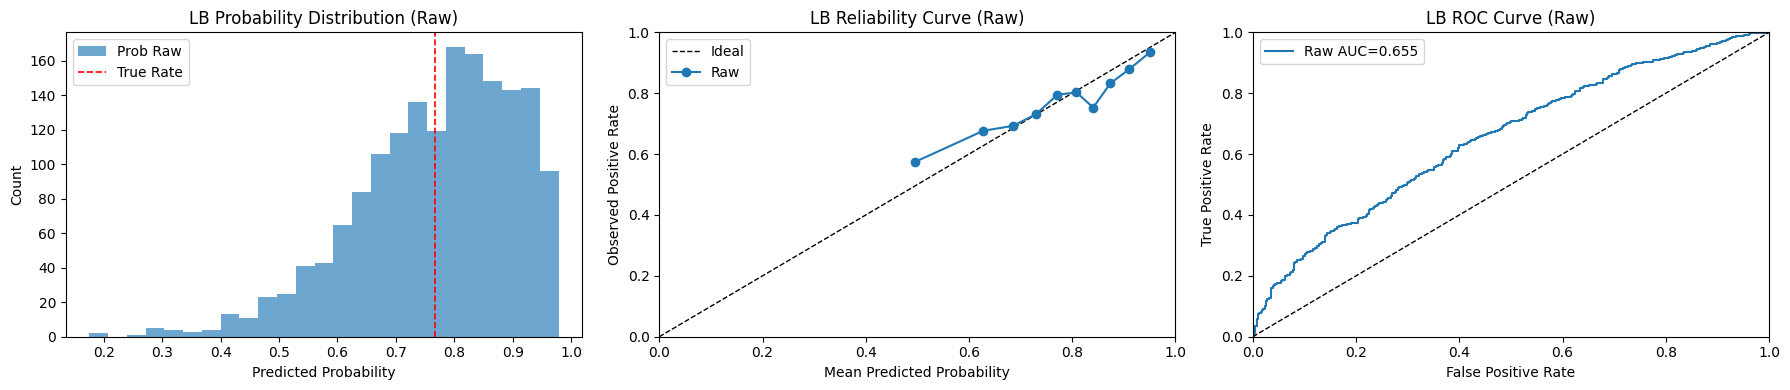

Top 10 contribution probability (raw) — LB


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
859,201700136,Jaden Hunter,2017,OLB,0.9379,0.978441,1,51.8126
1397,201800325,Chris Oats,2018,OLB,0.8964,0.976741,1,54.3564
10,201500133,Josh Barajas,2015,OLB,0.9413,0.976198,0,0.0
848,201700061,Jacob Phillips,2017,ILB,0.9719,0.975795,1,60.0596
855,201700100,Markail Benton,2017,OLB,0.9532,0.974516,1,52.019
1361,201800018,Adam Anderson,2018,OLB,0.9889,0.973379,1,70.3671
851,201700078,VanDarius Cowan,2017,OLB,0.9627,0.971618,1,58.0754
1377,201800166,Dallas Gant,2018,OLB,0.9322,0.969779,1,65.1211
1365,201800079,Payton Wilson,2018,OLB,0.9613,0.969772,1,90.1683
2280,202000057,Phillip Webb,2020,OLB,0.9725,0.969403,1,27.435



===== OL Classifier Diagnostics (Raw) =====


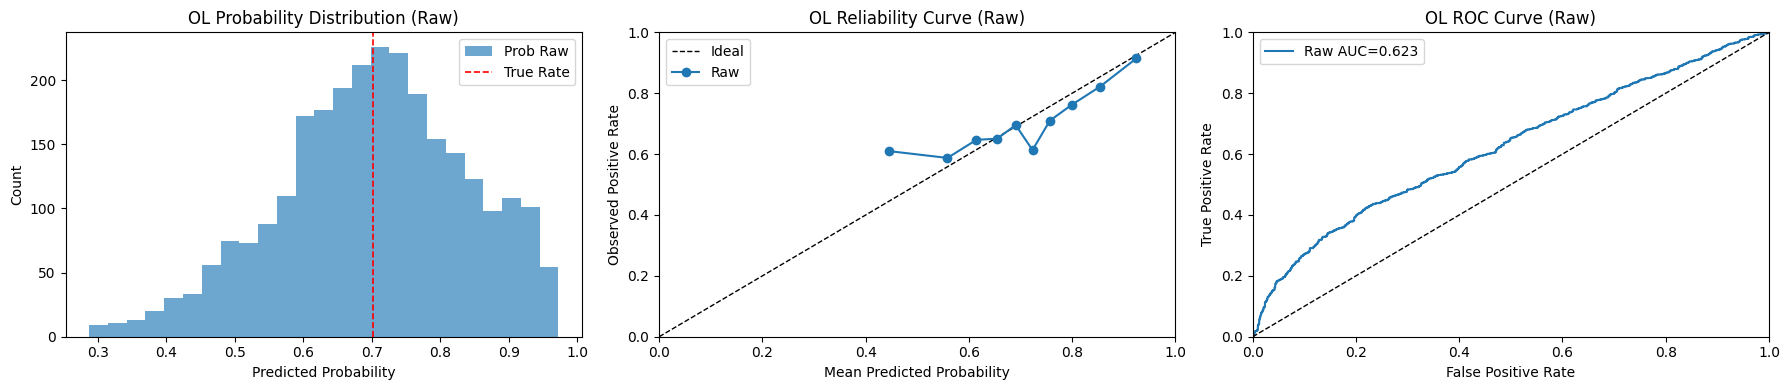

Top 10 contribution probability (raw) — OL


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
2976,202000060,Sedrick Van Pran,2020,OC,0.9712,0.972498,1,74.174
3603,202100124,Ben Christman,2021,IOL,0.9437,0.971229,1,37.0533
2989,202000114,Myles Murao,2020,OC,0.9496,0.970808,1,49.0859
7,201500062,Richie Petitbon,2015,OG,0.9696,0.968864,1,56.3313
3589,202100019,Donovan Jackson,2021,IOL,0.9900,0.967304,1,79.4449
600,201600086,Michael Onwenu,2016,OG,0.9571,0.965981,0,0.0
2388,201900074,Sean Rhyan,2019,OG,0.9671,0.964747,1,61.9733
2990,202000119,Chris Morris,2020,OG,0.9482,0.964511,0,0.0
593,201600039,Ben Bredeson,2016,OT,0.9798,0.964265,1,71.0645
1181,201700087,Netori Johnson,2017,OG,0.9588,0.964055,1,51.6896



===== QB Classifier Diagnostics (Raw) =====


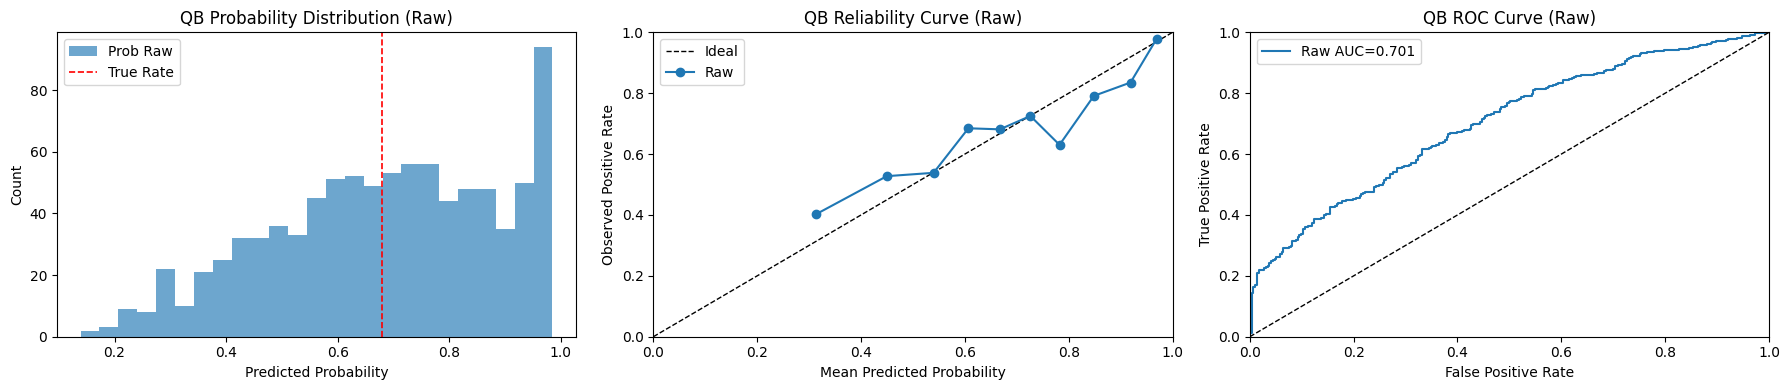

Top 10 contribution probability (raw) — QB


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
222,201600061,Brandon Peters,2016,PRO,0.9684,0.984915,1,62.6876
1,201500022,Blake Barnett,2015,PRO,0.9898,0.983984,1,58.6697
764,201800171,Spencer Sanders,2018,DUAL,0.9311,0.983583,1,76.0729
761,201800139,Adrian Martinez,2018,DUAL,0.9423,0.982570,1,79.5764
501,201700152,Myles Brennan,2017,PRO,0.9347,0.981335,1,55.9476
224,201600091,Dwayne Haskins,2016,PRO,0.9561,0.980390,1,82.3974
1272,202000059,Hudson Card,2020,DUAL,0.9721,0.980323,1,66.5843
999,201900011,Spencer Rattler,2019,PRO,0.9942,0.979884,1,76.6131
10,201500102,Travis Jonsen,2015,DUAL,0.9529,0.979525,0,0.0
759,201800091,Colson Yankoff,2018,DUAL,0.9564,0.978778,1,32.0618



===== RB Classifier Diagnostics (Raw) =====


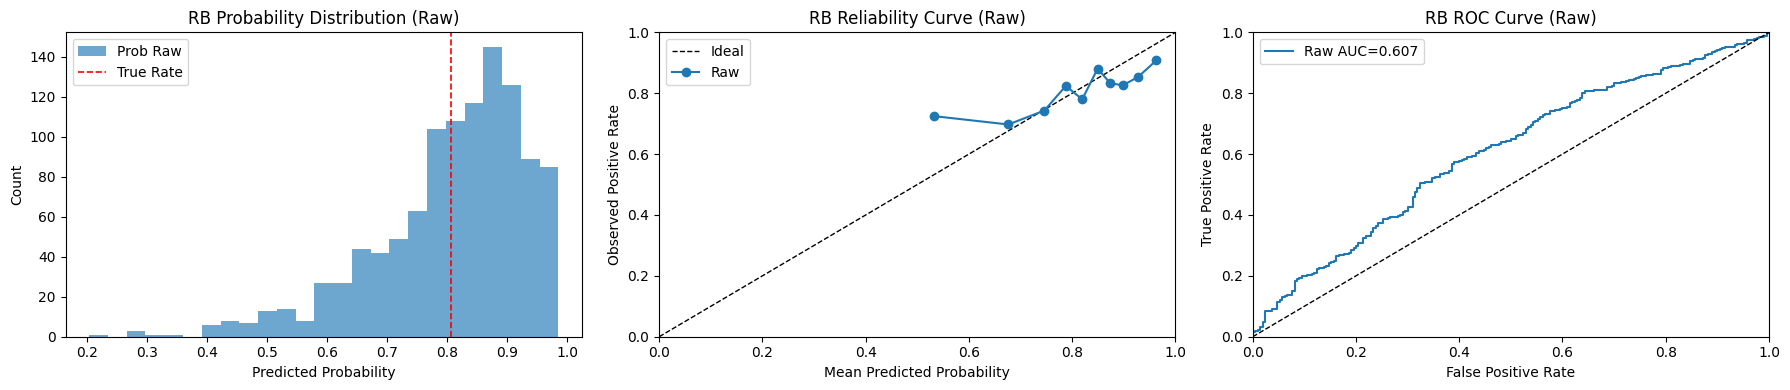

Top 10 contribution probability (raw) — RB


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
1037,201800173,Cam'Ron Harris,2018,RB,0.9308,0.985300,1,67.3605
1665,202000077,Roydell Williams,2020,RB,0.9650,0.983278,1,58.051
686,201700029,Khalan Laborn,2017,APB,0.9866,0.981393,1,56.2035
1676,202000173,Shaadie Clayton-Johnson,2020,RB,0.9280,0.981096,1,52.0119
1669,202000125,Daniyel Ngata,2020,APB,0.9464,0.980316,1,52.26
684,201700003,Cam Akers,2017,RB,0.9983,0.979669,1,78.9931
1343,201900119,Austin Jones,2019,RB,0.9471,0.978706,1,72.8454
701,201700214,Nathan Tilford,2017,RB,0.9176,0.978688,1,52.9351
1659,202000040,Tank Bigsby,2020,RB,0.9814,0.978513,1,80.2764
14,201500119,Saquon Barkley,2015,RB,0.9458,0.977849,1,90.7348



===== SPEC Classifier Diagnostics (Raw) =====


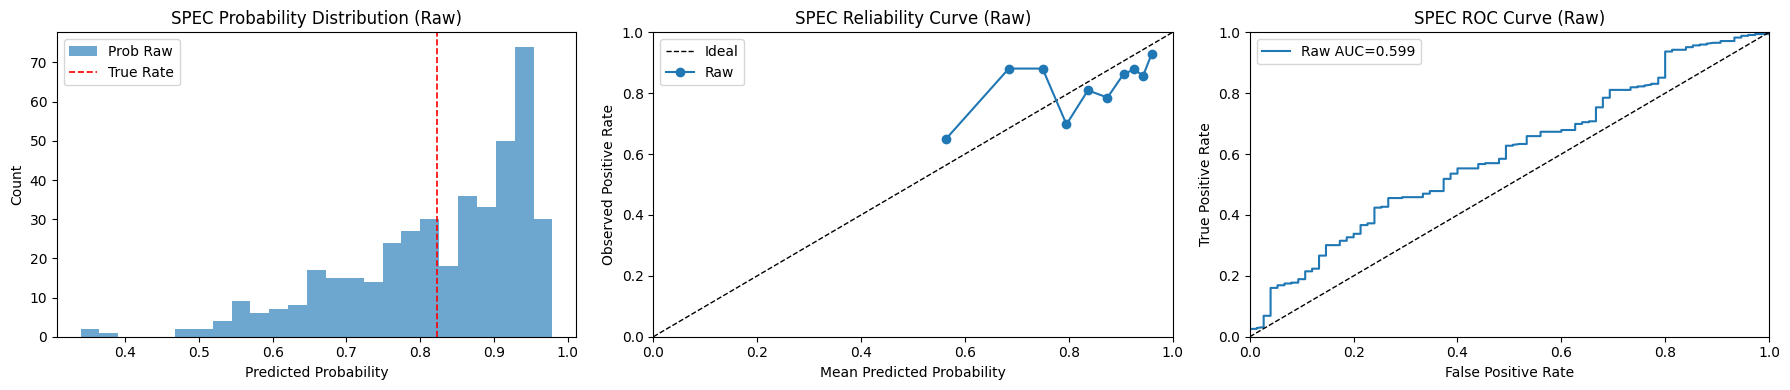

Top 10 contribution probability (raw) — SPEC


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
317,201901893,Tom Hutton,2019,P,0.8250,0.979538,1,57.2749
100,201601810,Van Soderberg,2016,K,0.8131,0.972090,1,30.1865
320,201901910,Ivan Mora,2019,K,0.8237,0.971786,1,58.2001
159,201701524,Cole Hahn,2017,K,0.8250,0.970722,1,51.7479
323,201902085,Alan Orona,2019,K,0.8167,0.970666,1,29.4662
5,201501458,Alex Kinney,2015,P,0.8308,0.969297,1,57.7074
252,201801853,Nick Mihalic,2018,P,0.8174,0.968799,1,56.5789
10,201501724,Drew Galitz,2015,P,0.8167,0.968112,1,55.9799
90,201601579,Alex Barbir,2016,K,0.8233,0.966459,1,59.7214
1,201500871,Charlie Beall,2015,K,0.8533,0.965391,0,0.0



===== TE Classifier Diagnostics (Raw) =====


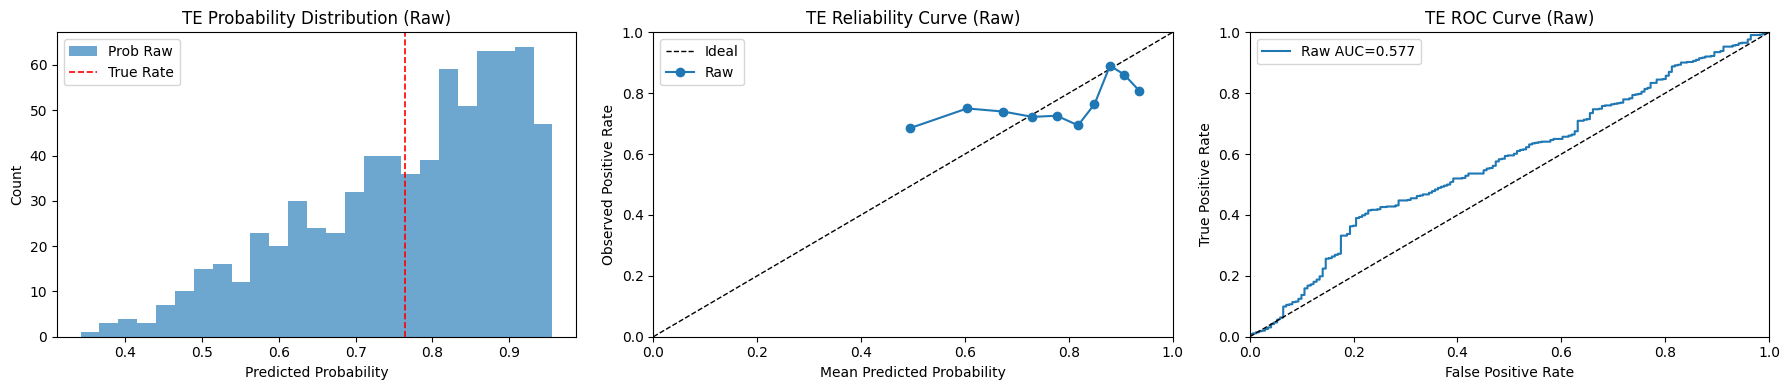

Top 10 contribution probability (raw) — TE


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
700,201901148,Luke Baker,2019,TE,0.8522,0.956676,1,37.6445
345,201700809,Austin Allen,2017,TE,0.8539,0.954288,1,67.5686
695,201901051,Niko Hea,2019,TE,0.8556,0.952627,1,60.1076
183,201600672,Jordan Wilson,2016,TE,0.8603,0.952080,1,67.7186
352,201700992,Lou Dorsey,2017,TE,0.8469,0.950710,1,71.6616
689,201900883,Sam Snyder,2019,TE,0.8637,0.949878,0,0.0
1025,202100932,Treylan Davis,2021,TE,0.8596,0.949741,1,64.1543
519,201800648,Bralen Taylor,2018,TE,0.8689,0.948177,0,0.0
1033,202101132,Charlie Browder,2021,TE,0.8522,0.948025,1,44.5686
864,202001180,Trevor Kardell,2020,TE,0.8511,0.947991,1,68.3395



===== WR Classifier Diagnostics (Raw) =====


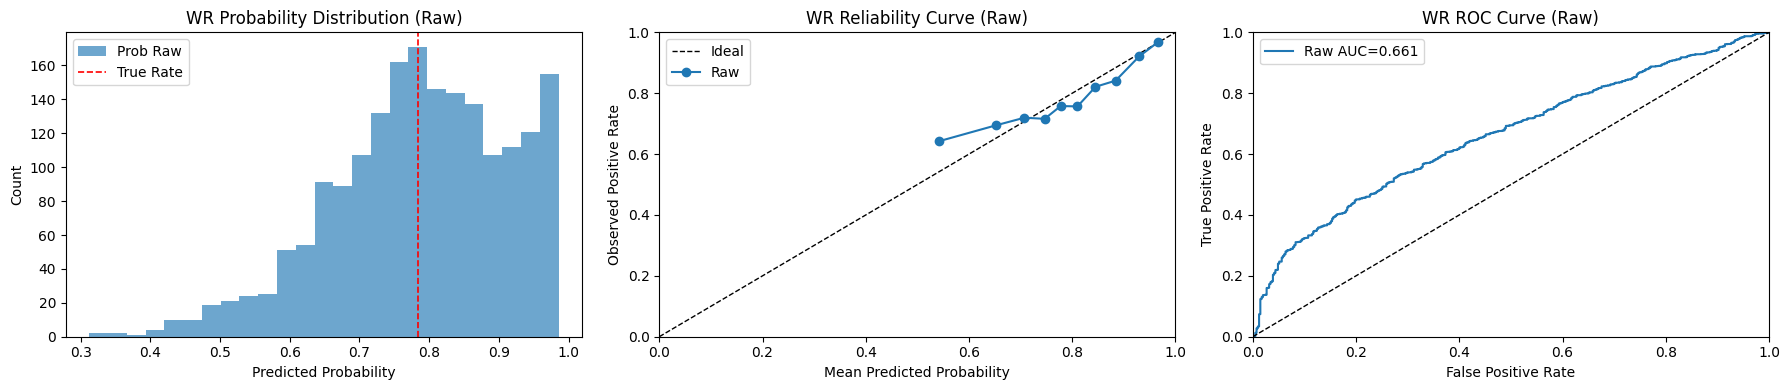

Top 10 contribution probability (raw) — WR


,player_id,name,year,position,rating,y_pred_prob_raw,y_true_binary,target_career_score_0_100
2573,202000025,Demond Demas,2020,WR,0.9890,0.985661,1,46.2662
2597,202000157,Jaquavion Fraziars,2020,WR,0.9317,0.984727,1,57.4235
2600,202000169,J.J. Evans,2020,WR,0.9285,0.982830,0,0.0
1552,201800127,Jalen Hall,2018,WR,0.9454,0.982805,0,0.0
2607,202000210,KeAndre Lambert-Smith,2020,WR,0.9198,0.982425,1,76.5829
1544,201800082,Kevin Austin,2018,WR,0.9601,0.981919,1,65.3261
1545,201800084,Ja'Marr Chase,2018,WR,0.9589,0.981398,1,87.413
1566,201800192,Jahan Dotson,2018,WR,0.9228,0.981346,1,82.9001
3086,202100079,Chris Hilton Jr.,2021,WR,0.9646,0.981124,1,60.3205
1542,201800069,Jacob Copeland,2018,WR,0.9651,0.980606,1,67.2353


In [45]:
# Classifier visual diagnostics: raw probabilities, reliability, ROC, top raw odds
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

for pos in FINAL_POSITION_GROUPS:
    pred_df = class_prediction_tables.get(pos)
    if pred_df is None or pred_df.empty:
        print(f"\n[{pos}] No classifier prediction table available.")
        continue

    vis_df = pred_df.copy()
    vis_df["y_true_binary"] = pd.to_numeric(vis_df["y_true_binary"], errors="coerce")
    vis_df["y_pred_prob_raw"] = pd.to_numeric(vis_df["y_pred_prob_raw"], errors="coerce")
    vis_df = vis_df.dropna(subset=["y_true_binary", "y_pred_prob_raw"]).copy()

    if vis_df.empty:
        print(f"\n[{pos}] No valid classifier rows for visualization.")
        continue

    print(f"\n===== {pos} Classifier Diagnostics (Raw) =====")

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].hist(vis_df["y_pred_prob_raw"], bins=25, alpha=0.65, label="Prob Raw")
    axes[0].axvline(vis_df["y_true_binary"].mean(), color="red", linestyle="--", linewidth=1.2, label="True Rate")
    axes[0].set_title(f"{pos} Probability Distribution (Raw)")
    axes[0].set_xlabel("Predicted Probability")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    def reliability_points(df_in: pd.DataFrame, prob_col: str, bins: int = 10):
        temp = df_in[["y_true_binary", prob_col]].copy()
        temp["bin"] = pd.qcut(temp[prob_col], q=bins, labels=False, duplicates="drop")
        grouped = temp.groupby("bin", observed=True).agg(
            mean_prob=(prob_col, "mean"),
            true_rate=("y_true_binary", "mean"),
            n=("y_true_binary", "size")
        ).reset_index(drop=True)
        return grouped

    rel_raw = reliability_points(vis_df, "y_pred_prob_raw")
    axes[1].plot([0, 1], [0, 1], "k--", linewidth=1.0, label="Ideal")
    axes[1].plot(rel_raw["mean_prob"], rel_raw["true_rate"], marker="o", label="Raw")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].set_title(f"{pos} Reliability Curve (Raw)")
    axes[1].set_xlabel("Mean Predicted Probability")
    axes[1].set_ylabel("Observed Positive Rate")
    axes[1].legend()

    if vis_df["y_true_binary"].nunique() > 1:
        fpr_raw, tpr_raw, _ = roc_curve(vis_df["y_true_binary"], vis_df["y_pred_prob_raw"])
        auc_raw = auc(fpr_raw, tpr_raw)
        axes[2].plot(fpr_raw, tpr_raw, label=f"Raw AUC={auc_raw:.3f}")
        axes[2].plot([0, 1], [0, 1], "k--", linewidth=1.0)
        axes[2].set_xlim(0, 1)
        axes[2].set_ylim(0, 1)
        axes[2].set_title(f"{pos} ROC Curve (Raw)")
        axes[2].set_xlabel("False Positive Rate")
        axes[2].set_ylabel("True Positive Rate")
        axes[2].legend()
    else:
        axes[2].text(0.5, 0.5, "ROC unavailable\n(single class)", ha="center", va="center")
        axes[2].set_axis_off()

    plt.tight_layout()
    plt.show()

    top_cols = [
        c for c in [
            "player_id", "name", "year", "position", "rating",
            "y_pred_prob_raw", "y_true_binary", "target_career_score_0_100"
        ] if c in vis_df.columns
    ]
    top10 = vis_df.sort_values("y_pred_prob_raw", ascending=False).head(10)
    print(f"Top 10 contribution probability (raw) — {pos}")
    display(top10[top_cols])

In [46]:
# Classifier future predictions: top raw odds by position (2022-2028)
for pos in FINAL_POSITION_GROUPS:
    future_df = class_future_prediction_tables.get(pos)
    if future_df is None or future_df.empty:
        print(f"\n[{pos}] No future classifier predictions available.")
        continue

    out_df = future_df.copy()
    out_df["contrib_prob_raw"] = pd.to_numeric(out_df["contrib_prob_raw"], errors="coerce")
    out_df["contrib_odds_raw"] = pd.to_numeric(out_df["contrib_odds_raw"], errors="coerce")
    out_df = out_df.dropna(subset=["contrib_prob_raw", "contrib_odds_raw"])

    print(f"\nTop future contribution odds (raw) — {pos}")
    display_cols = [
        c for c in [
            "player_id", "name", "year", "position", "rating",
            "contrib_prob_raw", "contrib_odds_raw"
        ] if c in out_df.columns
    ]
    display(out_df.sort_values("contrib_odds_raw", ascending=False).head(10)[display_cols])


Top future contribution odds (raw) — DB


,player_id,name,year,position,rating,contrib_prob_raw,contrib_odds_raw
6162,202600056,Zyan Gibson,2026,CB,0.9744,0.984882,65.148132
4614,202300039,A.J. Harris,2023,CB,0.9808,0.984825,64.897148
5609,202500063,AnQuon Fegans,2025,S,0.9674,0.984716,64.429680
4288,202200117,Tre'Quon Fegans,2022,CB,0.9530,0.984419,63.181419
4290,202200125,BJ Allen Jr.,2022,S,0.9505,0.983823,60.814796
4612,202300027,Dezz Ricks,2023,CB,0.9846,0.983246,58.688614
4998,202400012,Jaylen Mbakwe,2024,CB,0.9943,0.983088,58.129044
5004,202400037,Xavier Filsaime,2024,S,0.9835,0.982786,57.092251
4611,202300021,Peyton Bowen,2023,S,0.9864,0.982553,56.315285
5598,202500013,Na'eem Offord,2025,CB,0.9936,0.982415,55.867870



Top future contribution odds (raw) — EDGE


,player_id,name,year,position,rating,contrib_prob_raw,contrib_odds_raw
2826,202500118,Chase Linton,2025,Edge,0.9445,0.985226,66.688004
2413,202300192,AJ Green,2023,Edge,0.9254,0.985071,65.982399
2410,202300127,Chandavian Bradley,2023,Edge,0.9436,0.982889,57.443554
3377,202800072,Jayden Bell,2028,Edge,0.9368,0.982362,55.694530
2587,202400241,CJ Jackson,2024,Edge,0.9148,0.981747,53.784176
3107,202600158,Khamari Brooks,2026,Edge,0.9331,0.981113,51.945347
3101,202600120,Tristian Givens,2026,Edge,0.9475,0.980556,50.429302
2404,202300085,Caleb Herring,2023,Edge,0.9584,0.980522,50.340542
3323,202700186,Myles Smith,2027,Edge,0.9281,0.980239,49.604813
3315,202700090,Zane Rowe,2027,Edge,0.9607,0.979228,47.141773



Top future contribution odds (raw) — IDL


...

,player_id,name,year,position,rating,contrib_prob_raw,contrib_odds_raw
560,202302153,Mitch Lake,2023,P,0.8144,0.973643,36.940678
674,202602618,Jimmy Gregg,2026,P,0.8322,0.971784,34.440952
586,202402586,Lucas Osada,2024,P,0.8186,0.970526,32.927979
576,202402351,Kanyon Floyd,2024,P,0.8267,0.967184,29.472614
514,202201725,Will Bettridge,2022,K,0.8300,0.965286,27.807230
520,202201799,Alex Bacchetta,2022,P,0.8259,0.965155,27.698723
546,202301408,Tyler White,2023,P,0.8500,0.964019,26.792446
529,202201912,John Love,2022,K,0.8181,0.963749,26.585756
511,202201537,Alex McPherson,2022,K,0.8378,0.963704,26.551102
675,202602621,Tommy Bauchiero,2026,K,0.8317,0.963704,26.551102



Top future contribution odds (raw) — TE


,player_id,name,year,position,rating,contrib_prob_raw,contrib_odds_raw
1297,202301316,Will Anciaux,2023,TE,0.8531,0.955035,21.239506
1595,202501309,Austin Simmons,2025,TE,0.8608,0.954788,21.118181
1397,202400775,Noah Onyia,2024,TE,0.8750,0.953724,20.609514
1271,202300688,Jackson Carver,2023,TE,0.8769,0.953449,20.481958
1773,202600890,ArMari Towns,2026,TE,0.8744,0.953449,20.481958
1620,202501684,Tucker Kelleher,2025,TE,0.8517,0.953155,20.346825
1434,202401520,Monte Keener,2024,TE,0.8525,0.952874,20.219658
1289,202301109,Ben Marshall,2023,TE,0.8606,0.952781,20.177738
1596,202501311,Dylan Sims,2025,TE,0.8608,0.952672,20.129356
1300,202301384,Logan Blake,2023,TE,0.8508,0.952669,20.127867



Top future contribution odds (raw) — WR


,player_id,name,year,position,rating,contrib_prob_raw,contrib_odds_raw
3678,202300082,Ayden Williams,2023,WR,0.9593,0.985269,66.885201
3413,202200078,Kobe Prentice,2022,WR,0.9687,0.984922,65.323593
5360,202800120,Jacolby Campbell,2028,WR,0.9259,0.984885,65.157257
3676,202300078,Shelton Sampson Jr.,2023,WR,0.9610,0.984858,65.042671
4827,202600095,Jase Mathews,2026,WR,0.9575,0.984382,63.030045
3407,202200054,Kevin Coleman Jr.,2022,WR,0.9773,0.984047,61.685055
3679,202300095,Tyler Williams,2023,WR,0.9532,0.983896,61.096439
3415,202200088,Kyion Grayes,2022,WR,0.9627,0.983699,60.346691
3977,202400067,Ny Carr,2024,WR,0.9686,0.983588,59.930954
4816,202600011,Tristen Keys,2026,WR,0.9936,0.983431,59.351868


In [76]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import pairwise_distances

# Ignore warnings for binary flag casting
warnings.filterwarnings("ignore", category=UserWarning)

def get_player_comparables(
    target_player_id, 
    df_pool, 
    skill_cols, 
    flag_cols, 
    top_n=5,
    weights={"rating": 3.0, "size": 2.5, "skills": 1.0, "flags": 2.0, "state": 0.5}
):
    """
    Finds similarity within same position but ONLY among PRIOR recruiting classes.
    """
    # 0. Ensure IDs are strings for matching
    df_pool = df_pool.copy()
    df_pool['player_id'] = df_pool['player_id'].astype(str)
    target_id_str = str(target_player_id)
    
    # Check if target exists in pool
    if target_id_str not in df_pool['player_id'].values:
        raise ValueError(f"Player ID {target_id_str} not found in the provided dataset pool. Double check if this player is in a position group that has been loaded.")
        
    target_row = df_pool[df_pool['player_id'] == target_id_str].iloc[0]
    target_year = int(target_row['year'])
    target_pos = target_row['position']
    target_state = target_row['state']

    # 1. Filter for same position and PRIOR years
    df_comps = df_pool[
        (df_pool['position'] == target_pos) & 
        (pd.to_numeric(df_pool['year'], errors='coerce') < target_year)
    ].copy()
    
    if df_comps.empty:
        print(f"⚠️ No matches found in position {target_pos} from years prior to {target_year}.")
        return pd.DataFrame()

    # Prepend target player to the dataframe (idx 0)
    df = pd.concat([pd.DataFrame([target_row]), df_comps], ignore_index=True)
    target_idx = 0
    
    # Helper to safely scale and compute similarity
    def calculate_sim(data_df, weight_key):
        if data_df.empty or weights.get(weight_key, 0) == 0:
            return np.ones(len(df))
        
        # Squeeze out potential objects/strings by forcing numeric first
        data_df_numeric = data_df.apply(pd.to_numeric, errors='coerce')
        
        # Drop columns that are entirely NaNs (prevents mean() and scaler errors)
        data_df_numeric = data_df_numeric.dropna(axis=1, how='all')
        
        if data_df_numeric.empty:
            return np.ones(len(df))
            
        # Fill NaNs: try column mean, then fallback to 0
        mean_vals = data_df_numeric.mean()
        filled_data = data_df_numeric.fillna(mean_vals).fillna(0)
        
        # Scale to 0-1
        scaler = MinMaxScaler()
        try:
            scaled_vals = scaler.fit_transform(filled_data)
        except Exception:
            return np.ones(len(df))
        
        # Compute distance to target_idx
        target_vec = scaled_vals[target_idx]
        dists = np.linalg.norm(scaled_vals - target_vec, axis=1)
        
        # Convert to similarity: 1 - (dist / max_possible_dist)
        max_dist = np.sqrt(data_df_numeric.shape[1])
        sim = 1.0 - (dists / max_dist) if max_dist > 0 else np.ones(len(df))
        return np.nan_to_num(sim, nan=0.0)

    # ---------------------------------------------------------
    # 1. RATING SIMILARITY
    # ---------------------------------------------------------
    rating_sim = calculate_sim(df[['rating']], "rating")
    
    # ---------------------------------------------------------
    # 2. SIZE SIMILARITY
    # ---------------------------------------------------------
    size_cols = ['height_inches', 'weight_lbs']
    size_sim = calculate_sim(df[size_cols], "size")
    
    # ---------------------------------------------------------
    # 3. SKILL SIMILARITY
    # ---------------------------------------------------------
    active_skills = [c for c in skill_cols if c in df.columns]
    skill_sim = calculate_sim(df[active_skills], "skills") if active_skills else np.ones(len(df))
        
    # ---------------------------------------------------------
    # 4. FLAG SIMILARITY (Jaccard)
    # ---------------------------------------------------------
    active_flags = [c for c in flag_cols if c in df.columns]
    if active_flags and weights.get("flags", 0) > 0:
        flags_data = df[active_flags].fillna(0).astype(bool).values
        jaccard_dists = pairwise_distances(flags_data, flags_data[target_idx : target_idx + 1], metric='jaccard').flatten()
        flag_sim = 1.0 - np.nan_to_num(jaccard_dists, nan=1.0)
    else:
        flag_sim = np.ones(len(df))
        
    # ---------------------------------------------------------
    # 5. STATE MATCH SIMILARITY
    # ---------------------------------------------------------
    if pd.isna(target_state) or target_state == "" or weights.get("state", 0) == 0:
        state_sim = np.zeros(len(df))
    else:
        state_sim = (df['state'] == target_state).astype(float).values
        
    # ---------------------------------------------------------
    # 6. BLEND INTO FINAL SIMILARITY SCORE
    # ---------------------------------------------------------
    total_weight = sum(weights.values())
    
    final_sim_score = (
        (rating_sim * weights["rating"]) +
        (size_sim * weights["size"]) +
        (skill_sim * weights["skills"]) +
        (flag_sim * weights["flags"]) +
        (state_sim * weights["state"])
    ) / total_weight
    
    df['similarity_score'] = np.round(final_sim_score * 100, 2)
    
    # ---------------------------------------------------------
    # 7. FORMAT AND RETURN RESULTS
    # ---------------------------------------------------------
    comps = df.drop(index=target_idx).sort_values('similarity_score', ascending=False).head(top_n)
    
    display_cols = [
        'player_id', 'name', 'year', 'similarity_score', 
        'rating', 'height_inches', 'weight_lbs', 'state'
    ]
    
    print(f"🎯 Target Player: {target_row['name']} ({target_row['year']}) | Rating: {target_row['rating']} | {target_row['height_inches']}\" / {target_row['weight_lbs']} lbs | {target_state}")
    print(f"Searching for historical comparables from classes prior to {target_year}... ({len(df_comps)} candidates searched)")
    print("-" * 80)
    
    return comps[display_cols]

# ==========================================
# RE-CONSTRUCT PLAYER UNIVERSE (POOL)
# ==========================================
all_pos_rows = []
for pos, df_pos in datasets.items():
    all_pos_rows.append(df_pos)
for pos, df_future in inference_datasets.items():
    all_pos_rows.append(df_future)

if all_pos_rows:
    player_universe = pd.concat(all_pos_rows, ignore_index=True)
else:
    player_universe = pd.DataFrame()

# Identify feature columns for comparisons
flag_cols = [c for c in player_universe.columns if c.startswith('flag_')]
skill_cols = [c for c in player_universe.columns if c.startswith('skill_')]

# ==========================================
# EXAMPLE USAGE
# ==========================================
target_id = "202600004"
try:
    comps_df = get_player_comparables(target_id, player_universe, skill_cols, flag_cols, top_n=5)
    display(comps_df)
except ValueError as e:
    print(f"❌ Error: {e}")
    if not player_universe.empty:
        print(f"\nExample of available player IDs: {player_universe['player_id'].head(10).tolist()}")
except Exception as e:
    print(f"❌ Unexpected Error: {e}")
    import traceback
    traceback.print_exc()

🎯 Target Player: Jackson Cantwell (2026) | Rating: 0.999 | 79.5" / 325.0 lbs | MO
Searching for historical comparables from classes prior to 2026... (3001 candidates searched)
--------------------------------------------------------------------------------


,player_id,name,year,similarity_score,rating,height_inches,weight_lbs,state
2318,202300010,Kadyn Proctor,2023,92.78,0.9939,79.0,330.0,IA
632,201700009,Walker Little,2017,91.32,0.9952,79.0,315.0,TX
1869,202100008,Amarius Mims,2021,90.84,0.9956,79.0,315.0,GA
630,201700004,Alex Leatherwood,2017,90.39,0.9981,78.0,327.0,FL
631,201700005,Foster Sarell,2017,90.39,0.9968,78.5,311.0,WA
